# **2º Projeto de Aprendizagem Automática Não Supervisionada:**
## Sistema de recomendação videojogos
por: **Ilie Iftime - 112779, Inês Cruz - 123557, Sofia Quintino - 123554**

_________________________________________________________________________________________________________________________________________________________________________

## **Introdução**

Neste projeto de aprendizagem automática não supervisionada, iremos construir um sistema de recomendação de vídeo jogos utilizando técnicas avançadas como detecção de outliers (Isolation Forest e Local Outlier Factor), algoritmos de associação (Apriori) e/ou mapas auto-organizáveis (Self-Organizing Maps - SOMs).

O objetivo será analisar um conjunto de dados de vendas globais de videojogos, utilizando bibliotecas como `pandas`, `numpy`, `scikit-learn`, entre outras, para manipular e explorar os dados. O intuito principal é identificar padrões e recomendações que possam ajudar na seleção de jogos baseados em preferências específicas ou características semelhantes.

**O trabalho será dividido nas seguintes partes:**
1. Definição do problema
2. Caracterização do dataset
3. Data Wrangling
4. Exploratory Data Analysis
5. Algoritmos de outliers detection
6. Construção dos sistemas de recomendação com apriori/SOMs
7. Comparação de algoritmos
8. Conclusão
9. Bibliografia

## **1. Definição do problema**

Este projeto aborda a construção de um sistema de recomendação baseado em técnicas não supervisionadas. O objetivo é analisar dados históricos de vendas globais de vídeo jogos, utilizando métodos de deteção de outliers, associação e clustering (Apriori, SOM, k-Means ou DBSCAN) para identificar padrões ocultos e associações significativas entre diferentes variáveis tais como género, plataforma, ano e editora.

Pretende-se com isto fornecer insights sobre possíveis recomendações personalizadas, melhorar estratégias de marketing e auxiliar na compreensão dos fatores que influenciam o sucesso comercial dos jogos.


## **2. Caracterização do Dataset**

Este dataset contém informações detalhadas sobre vendas globais de vídeo jogos, incluindo variáveis como:

- **rank**: Posição do jogo em vendas globais.
- **name**: Nome do jogo.
- **platform**: Plataforma na qual o jogo foi lançado (por ex., PS4, Xbox).
- **year**: Ano de lançamento.
- **Genre**: Género do jogo.
- **publisher**: Empresa que publicou o jogo.
- **na_sales, eu_sales, jp_sales, other_sales, global_sales**: Vendas nas diversas regiões e globalmente.

O dataset original pode ser consultado aqui:  
**[Video Games Sales Dataset - Kaggle](https://www.kaggle.com/datasets/ulrikthygepedersen/video-games-sales/data)**  


### **Imports a utilizar no notebook**

In [67]:
#!pip install mlxtend
#!pip install minisom
#!pip install ipywidgets
#!pip install dash pandas scikit-learn umap-learn plotly mlxtend requests
#Se for no Jupyter:
#!pip install jupyter-dash
#!pip install dash
#!pip install requests
#!pip install dash_table

In [68]:
from IPython.display import display, Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
import warnings
import os
import requests
import dash
from dash import Dash, html, dcc, dash_table
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import ColumnTransformer
from matplotlib.lines import Line2D
from minisom import MiniSom
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import unidecode
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [69]:
#Dados para a tabela do teu dataset de vendas de videojogos
data = {
    "Atributo": ["rank", "name", "platform", "year", "genre", "publisher",
                 "na_sales", "eu_sales", "jp_sales", "other_sales", "global_sales"],
    
    "Nome": ["classificação", "nome", "plataforma", "ano_lancamento", "género", "editora",
             "vendas_na", "vendas_eu", "vendas_jp", "outras_vendas", "vendas_globais"],
    
    "Tipo de Variável": ["inteiro", "string", "string", "inteiro", "string", "string",
                         "float", "float", "float", "float", "float"],
    
    "Descrição": [
        "Posição do jogo nas vendas globais",
        "Nome do vídeo jogo",
        "Plataforma na qual o jogo foi lançado (ex: Switch, Xbox)",
        "Ano em que o jogo foi lançado",
        "Categoria/género do jogo",
        "Empresa que publicou o jogo",
        "Vendas na América do Norte (em milhões de cópias)",
        "Vendas na Europa (em milhões de cópias)",
        "Vendas no Japão (em milhões de cópias)",
        "Vendas em outras regiões (em milhões de cópias)",
        "Vendas globais totais (em milhões de cópias)"
    ]
}

#Criar o DataFrame
df_video_games = pd.DataFrame(data)

#Exibir a tabela
print(df_video_games)

display(df_video_games)

        Atributo            Nome Tipo de Variável  \
0           rank   classificação          inteiro   
1           name            nome           string   
2       platform      plataforma           string   
3           year  ano_lancamento          inteiro   
4          genre          género           string   
5      publisher         editora           string   
6       na_sales       vendas_na            float   
7       eu_sales       vendas_eu            float   
8       jp_sales       vendas_jp            float   
9    other_sales   outras_vendas            float   
10  global_sales  vendas_globais            float   

                                            Descrição  
0                  Posição do jogo nas vendas globais  
1                                  Nome do vídeo jogo  
2   Plataforma na qual o jogo foi lançado (ex: Swi...  
3                       Ano em que o jogo foi lançado  
4                            Categoria/género do jogo  
5                         E

,Atributo,Nome,Tipo de Variável,Descrição
0,rank,classificação,inteiro,Posição do jogo nas vendas globais
1,name,nome,string,Nome do vídeo jogo
2,platform,plataforma,string,Plataforma na qual o jogo foi lançado (ex: Swi...
3,year,ano_lancamento,inteiro,Ano em que o jogo foi lançado
4,genre,género,string,Categoria/género do jogo
5,publisher,editora,string,Empresa que publicou o jogo
6,na_sales,vendas_na,float,Vendas na América do Norte (em milhões de cópias)
7,eu_sales,vendas_eu,float,Vendas na Europa (em milhões de cópias)
8,jp_sales,vendas_jp,float,Vendas no Japão (em milhões de cópias)
9,other_sales,outras_vendas,float,Vendas em outras regiões (em milhões de cópias)


Observa-se que este conjunto de dados é composto por variáveis qualitativas e quantitativas. 

As variáveis qualitativas nominais do tipo **string** são:  
- **"nome"**, **"plataforma"**, **"género"** e **"editora"**, representando respetivamente o título do jogo, a plataforma onde foi lançado, o género do jogo e a empresa responsável pela publicação.

As variáveis quantitativas discretas são:  
- **"classificação"** e **"ano_lancamento"**, indicando a posição em vendas globais e o ano do lançamento.

As restantes variáveis são quantitativas contínuas do tipo **float** que descrevem as vendas em milhões de cópias nas diferentes regiões (**"vendas_na"**, **"vendas_eu"**, **"vendas_jp"**, **"outras_vendas"**) e as vendas totais globais (**"vendas_globais"**).


## **3. Data Wrangling**

Nesta fase, realizaremos o processo inicial de preparação e limpeza dos dados:

- Tradução das variáveis originais para Português.
- Verificação e análise de valores ausentes.
- Tratamento específico dos valores ausentes:
  - **Ano de lançamento** (`ano_lancamento`): substituir por valor médio.
  - **Editora** (`editora`): substituir por produtora associada ao género do jogo e região dominante nas vendas (especialmente, atribuir "Produtora Asiática" para jogos RPG com vendas predominantes no Japão).
- Apresentação da contagem de valores únicos por coluna.


In [70]:
#Obter a forma (número de linhas e colunas) do dataframe
print(f"Número de entradas por colunas {df.shape}")

#Carregar o dataset
df = pd.read_csv('video_games_sales.csv')

print(df.head())

Número de entradas por colunas (16598, 23)
   rank                      name platform    year         genre publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   na_sales  eu_sales  jp_sales  other_sales  global_sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


### Tradução das variáveis para português

De forma a facilitar a leitura e interpretação de resultados, os nomes das variáveis serão traduzidos para português

In [71]:
#Traduzir os nomes das colunas para Português
df.rename(columns={
    'rank': 'classificacao',
    'name': 'nome',
    'platform': 'plataforma',
    'year': 'ano_lancamento',
    'genre': 'genero',
    'publisher': 'editora',
    'na_sales': 'vendas_na',
    'eu_sales': 'vendas_eu',
    'jp_sales': 'vendas_jp',
    'other_sales': 'outras_vendas',
    'global_sales': 'vendas_globais'
}, inplace=True)

#Mostrar resultado inicial após tradução
display(df.head())

,classificacao,nome,plataforma,ano_lancamento,genero,editora,vendas_na,vendas_eu,vendas_jp,outras_vendas,vendas_globais
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Análise de Valores Ausentes

Realizaremos agora uma verificação detalhada dos valores ausentes em cada coluna do dataset para determinar quais necessitam de tratamento específico.

In [72]:
#Contagem de valores ausentes
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:\n", ausentes)

#Percentagem de valores ausentes
percentagem_ausentes = (ausentes / len(df)) * 100
print("\nPercentagem de valores ausentes:\n", percentagem_ausentes)

Valores ausentes por coluna:
 classificacao       0
nome                0
plataforma          0
ano_lancamento    271
genero              0
editora            58
vendas_na           0
vendas_eu           0
vendas_jp           0
outras_vendas       0
vendas_globais      0
dtype: int64

Percentagem de valores ausentes:
 classificacao     0.000000
nome              0.000000
plataforma        0.000000
ano_lancamento    1.632727
genero            0.000000
editora           0.349440
vendas_na         0.000000
vendas_eu         0.000000
vendas_jp         0.000000
outras_vendas     0.000000
vendas_globais    0.000000
dtype: float64


### Tratamento dos Valores Ausentes

Para as variáveis que possuem valores ausentes, aplicaremos o seguinte tratamento específico:

- **Ano de lançamento**: substituição dos valores ausentes pela média dos anos disponíveis.
- **Editora**: substituição dos valores ausentes pela identificação da produtora baseada no género e região com maior venda. Exemplo prático: jogos com vendas predominantes no Japão receberão o valor "Produtora Asiática".


In [73]:
#Preencher NaN em 'ano_lancamento' pela média (sem inplace direto)
media_ano = int(df['ano_lancamento'].mean())
df['ano_lancamento'] = df['ano_lancamento'].fillna(media_ano)

#Mapeamento das regiões para produtoras
mapping = {
    'vendas_jp':    'Produtora Asiática',
    'vendas_na':    'Produtora Norte-Americana',
    'vendas_eu':    'Produtora Europeia',
    'outras_vendas':'Produtora Outra'
}

#Função para definir 'editora' com fallback para 'Produtora Outra'
def definir_editora(row):
    if pd.isna(row['editora']):
        regiao_max = row[['vendas_na','vendas_eu','vendas_jp','outras_vendas']].idxmax()
        return mapping.get(regiao_max, 'Produtora Outra')
    return row['editora']

#Aplicar diretamente no df original
df['editora'] = df.apply(definir_editora, axis=1)

#Verificação final de valores ausentes
print("Valores ausentes após tratamento:\n", df.isnull().sum())


Valores ausentes após tratamento:
 classificacao     0
nome              0
plataforma        0
ano_lancamento    0
genero            0
editora           0
vendas_na         0
vendas_eu         0
vendas_jp         0
outras_vendas     0
vendas_globais    0
dtype: int64


### Valores Únicos por Coluna

Após o tratamento dos valores ausentes, procedemos à criação de uma tabela que mostra o número de valores únicos por coluna. Esta análise auxilia na compreensão da diversidade dos dados disponíveis no dataset.

In [74]:
#Tabela com a contagem de valores únicos
unicos = df.nunique().reset_index()
unicos.columns = ['Coluna', 'Valores Únicos']

#Exibir a tabela
display(unicos)

,Coluna,Valores Únicos
0,classificacao,16598
1,nome,11493
2,plataforma,31
3,ano_lancamento,39
4,genero,12
5,editora,581
6,vendas_na,409
7,vendas_eu,305
8,vendas_jp,244
9,outras_vendas,157


### Lista de Géneros de Jogo

De seguida, apresentamos todos os géneros presentes no dataset, para termos um panorama completo das categorias de jogos com que vamos trabalhar.

In [75]:
#Listar todos os géneros únicos do dataset
generos_unicos = df['genero'].dropna().unique()

#Ordenar para facilitar a leitura
generos_unicos = sorted(generos_unicos)

#Exibir quantidade e lista de géneros
print(f"Total de géneros encontrados: {len(generos_unicos)}\n")
for genero in generos_unicos:
    print(f"- {genero}")

Total de géneros encontrados: 12

- Action
- Adventure
- Fighting
- Misc
- Platform
- Puzzle
- Racing
- Role-Playing
- Shooter
- Simulation
- Sports
- Strategy


#### Visualizar as plataformas de jogos

In [76]:
print(df["plataforma"].unique())

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


Verifica-se uma vasta rede de consolas ao longo das decádas, contudo existe a ausência do Android e IOS.

#### Feature Engineering 

**Década, Região Dominante e Franquia**  
- _Faixa Temporal_: transforma o ano de lançamento em categorias de década, usando limites reais (1980–89, 1990–99, etc.).  
- _Região Dominante_: escolhe, por linha, qual coluna de vendas (`vendas_na`, `vendas_eu`, `vendas_jp`, `outras_vendas`) é máxima e mapeia para siglas de região.  
- _Franquia_: extrai as duas primeiras palavras do nome do jogo (minúsculas) para identificar séries ou franquias.

Antes de prosseguir para a criação das variáveis sucesso em determinada região, iremos verificar a média das vendas para termos um valor de threshold.

In [77]:
print(df[["vendas_na", "vendas_eu", "vendas_jp", "outras_vendas", "vendas_globais"]].mean())

vendas_na         0.264667
vendas_eu         0.146652
vendas_jp         0.077782
outras_vendas     0.048063
vendas_globais    0.537441
dtype: float64


Criação de faixas temporais no dataset para aplicação do algoritmo Apriori, e criação da feature "jogo_franquia", que identifica se um determinado jogo possui antecessores ou sucessores.

In [78]:
#Faixa temporal por décadas
def decada(ano):
    if ano < 1990:   return 'anos_80'
    elif ano < 2000: return 'anos_90'
    elif ano < 2010: return 'anos_2000'
    elif ano < 2020: return 'anos_2010'
    else:            return 'anos_2020'

df['faixa_temporal'] = df['ano_lancamento'].apply(decada)

#Região dominante de vendas
df['regiao_dominante'] = (
    df[['vendas_na','vendas_eu','vendas_jp','outras_vendas']]
      .idxmax(axis=1)
      .map({
         'vendas_na':    'NA',
         'vendas_eu':    'EU',
         'vendas_jp':    'JP',
         'outras_vendas':'Other'
      })
)

#Identificar franquia (2 primeiras palavras do nome)
df['jogo_franquia'] = (
    df['nome']
      .str.split()
      .str[:2]
      .str.join(' ')
      .str.lower()
)


**Franquia de Sucesso**  
- Conta quantos títulos existem por `jogo_franquia`.  
- Marca `franquia_sucesso = true` para franquias com ≥ 3 jogos, caso contrário `false`. Isso substitui o antigo binning de classificações.


In [79]:
#Contar jogos por franquia
contagem_franquia = df['jogo_franquia'].value_counts()

#Franquia é "bem estabelecida" se tiver >= 3 títulos
df['franquia_sucesso'] = df['jogo_franquia'].map(lambda fq: fq if fq in contagem_franquia.index else fq)
df['franquia_sucesso'] = df['jogo_franquia'].map(lambda fq: 'true' if contagem_franquia.get(fq,0) >= 3 else 'false')

**Flags de Sucesso Regional & Sucesso de Vendas**  
- Preenche NaNs de vendas com 0 e calcula a média real de cada região.  
- Gera `sucesso_na`, etc. como `"true"`/`"false"` comparando cada valor de venda à média regional.  
- Cria `sucesso_vendas` marcando como `"true"` os jogos no top 30% de vendas globais (≥ 70º percentil), senão `"false"`.

In [80]:
#Preencher NaNs nas vendas
vcols = ['vendas_na','vendas_eu','vendas_jp','outras_vendas','vendas_globais']
df[vcols] = df[vcols].fillna(0)

#Médias regionais
medias = df[['vendas_na','vendas_eu','vendas_jp','outras_vendas']].mean()

#Flags regionais (“true”/“false”)
for reg in ['na','eu','jp','outras']:
    col = f'vendas_{reg}' if reg!='outras' else 'outras_vendas'
    flag = f'sucesso_{reg}'
    df[flag] = (df[col] > medias[col]).map({True:'true', False:'false'})

#Top 30% de vendas globais
limiar_70 = df['vendas_globais'].quantile(0.70)
df['sucesso_vendas'] = (df['vendas_globais'] >= limiar_70).map({True:'true', False:'false'})

### Variáveis úteis para o algoritmo de regras de associação apriori

Além das features individuais, podemos criar **variáveis compostas** que capturem interações interessantes:

- **franquia_sucesso**: concatena `jogo_franquia` + `regiao_dominante` (ex.: `"call of_JP"`) para capturar padrões de franquias populares em certas regiões.  
- **perfil_jogo**: combina `genero` + `plataforma` (ex.: `"RPG_PS4"`) para analisar preferências multi-atributo.  


In [81]:
#Franquia de sucesso: concatena jogo_franquia + "_" + regiao_dominante
df['franquia_sucesso'] = (
    df['jogo_franquia'].astype(str) + "_" + 
    df['regiao_dominante'].astype(str)
)

#Perfil de jogo: concatena genero + "_" + plataforma
df['perfil_jogo'] = (
    df['genero'].astype(str) + "_" + 
    df['plataforma'].astype(str)
)

Cópias separadas para os datasets dedicados ao apriori e SOMs.

In [82]:
#Cópias para Apriori e SOM + codificação 

#df_apriori: só colunas categóricas em string
vars_apriori = ["nome",
    'genero','plataforma','editora',
    'faixa_temporal','regiao_dominante','jogo_franquia',
    'franquia_sucesso','sucesso_na','sucesso_eu','sucesso_jp','sucesso_outras',
    'sucesso_vendas', 'perfil_jogo', "classificacao"
]
df_apriori = df[vars_apriori].astype(str).copy()

#cópia para criar df_som
vars_som = ["nome",'genero','plataforma','editora','classificacao','ano_lancamento'] + vcols + \
           ['faixa_temporal','regiao_dominante','jogo_franquia',
            'franquia_sucesso','sucesso_na','sucesso_eu','sucesso_jp','sucesso_outras','sucesso_vendas']
df_som = df[vars_som].copy()

Após a criação dos dois datasets vamos aplicar o label encoder para transformar as features em string no dataset df_apriori.

In [83]:
#Lista de colunas a separar nos 2 datasets
num_cols_scaled = [
    'ano_lancamento',
    'vendas_na',
    'vendas_eu',
    'vendas_jp',
    'outras_vendas',
    'vendas_globais'
]

cols= [
    'genero',
    'plataforma',
    'editora',
    "classificacao",
    'faixa_temporal',
    'regiao_dominante',
    'jogo_franquia',
    'franquia_sucesso',
    'sucesso_na',
    'sucesso_eu',
    'sucesso_jp',
    'sucesso_outras',
    'sucesso_vendas'
]


le = LabelEncoder()
for col in cols:
    df_som[col] = le.fit_transform(df_som[col].astype(str))

#Agora junta num único DataFrame as features finais
df_features = pd.concat([
    df_som[num_cols_scaled],      
    df_som[cols]      
], axis=1)

Verificação das features e dos valores ausentes.

In [84]:
print(df_apriori.isna().sum())

nome                0
genero              0
plataforma          0
editora             0
faixa_temporal      0
regiao_dominante    0
jogo_franquia       0
franquia_sucesso    0
sucesso_na          0
sucesso_eu          0
sucesso_jp          0
sucesso_outras      0
sucesso_vendas      0
perfil_jogo         0
classificacao       0
dtype: int64


In [85]:
print(df_apriori.dtypes)

nome                object
genero              object
plataforma          object
editora             object
faixa_temporal      object
regiao_dominante    object
jogo_franquia       object
franquia_sucesso    object
sucesso_na          object
sucesso_eu          object
sucesso_jp          object
sucesso_outras      object
sucesso_vendas      object
perfil_jogo         object
classificacao       object
dtype: object


In [86]:
print(df_som.dtypes)

nome                 object
genero                int32
plataforma            int32
editora               int32
classificacao         int32
ano_lancamento      float64
vendas_na           float64
vendas_eu           float64
vendas_jp           float64
outras_vendas       float64
vendas_globais      float64
faixa_temporal        int32
regiao_dominante      int32
jogo_franquia         int32
franquia_sucesso      int32
sucesso_na            int32
sucesso_eu            int32
sucesso_jp            int32
sucesso_outras        int32
sucesso_vendas        int32
dtype: object


Na fase de Data Wrangling, foram aplicadas diversas técnicas para preparar o dataset de vendas de videojogos antes da análise. Este processo envolveu:

1. Renomeação de colunas para nomes em português, facilitando a interpretação (ex.: platform → plataforma, year → ano_lancamento).
2. Tratamento de valores nulos, removendo ou preenchendo dados em falta para garantir consistência nos algoritmos posteriormente aplicados.
3. Conversão dos tipos de dados, assegurando que datas, números e categorias estivessem no formato adequado.
4. Codificação de variáveis categóricas com LabelEncoder, transformando textos como nomes de plataformas, géneros e editoras em valores numéricos.
5. Criação de novas features, como:
- jogo_franquia: indica se um jogo pertence a uma franquia com predecessores ou sucessores.
- Faixas temporais (por exemplo, décadas) para análise por períodos de tempo.

Estas transformações permitiram limpar e enriquecer o dataset, tornando-o apropriado para a aplicação dos algoritmos de aprendizagem não supervisionada (Apriori, SOM, etc.).

## 4. EDA (Exploratory Data Analysis)

### Análise Exploratória Inicial

Para compreender melhor o comportamento dos dados antes da aplicação de algoritmos, foram realizadas duas análises preliminares:

1. Visualização da distribuição dos géneros disponíveis no conjunto de dados.
2. Tabela com os 10 jogos melhor classificados, com base nas variáveis quantitativas como classificação, vendas por região e vendas globais.

Estas análises permitem identificar padrões de preferência e tendências de consumo, oferecendo uma base sólida para a aplicação das técnicas de recomendação não supervisionadas.

Gera estatísticas descritivas para todas as colunas numéricas do dataset.

In [87]:
df.describe()

,classificacao,ano_lancamento,vendas_na,vendas_eu,vendas_jp,outras_vendas,vendas_globais
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.399807,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.781426,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


Gera estatísticas descritivas para o dataset filtrado para o algoritmo Apriori (df_apriori), permitindo analisar a distribuição de valores.

In [88]:
df_apriori.describe()

,nome,genero,plataforma,editora,faixa_temporal,regiao_dominante,jogo_franquia,franquia_sucesso,sucesso_na,sucesso_eu,sucesso_jp,sucesso_outras,sucesso_vendas,perfil_jogo,classificacao
count,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598,16598
unique,11493,12,31,581,5,4,7200,8133,2,2,2,2,2,293,16598
top,Need for Speed: Most Wanted,Action,DS,Electronic Arts,anos_2000,NA,madden nfl,madden nfl_NA,false,false,false,false,false,Sports_PS2,1
freq,12,3316,2163,1351,9479,10113,96,95,12796,13102,13654,13109,11517,400,1


Apresenta estatísticas descritivas do dataset preparado para o algoritmo SOM (Self-Organizing Map), permitindo analisar a distribuição das variáveis numéricas utilizadas na clusterização.

In [89]:
df_som.describe()

,genero,plataforma,editora,classificacao,ano_lancamento,vendas_na,vendas_eu,vendas_jp,outras_vendas,vendas_globais,faixa_temporal,regiao_dominante,jogo_franquia,franquia_sucesso,sucesso_na,sucesso_eu,sucesso_jp,sucesso_outras,sucesso_vendas
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,4.928124,15.797988,295.077539,8298.500000,2006.399807,0.264667,0.146652,0.077782,0.048063,0.537441,0.773406,1.475057,3710.720328,4167.310339,0.229064,0.210628,0.177371,0.210206,0.306121
std,3.762015,8.392298,178.607626,4791.574219,5.781426,0.816683,0.505351,0.309291,0.188588,1.555028,1.236332,0.738478,2056.743095,2315.942019,0.420243,0.407767,0.381994,0.407467,0.460895
min,0.000000,0.000000,0.000000,0.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,7.000000,137.000000,4149.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,1.000000,1972.000000,2209.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,16.000000,323.000000,8298.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,0.000000,2.000000,3729.000000,4185.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,21.000000,459.000000,12447.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000,1.000000,2.000000,5555.750000,6229.750000,0.000000,0.000000,0.000000,0.000000,1.000000
max,11.000000,30.000000,580.000000,16597.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000,4.000000,3.000000,7199.000000,8132.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [90]:
#Definição de palete de cores
sns.set_theme(style="whitegrid", palette="Set2")

Esta análise apresenta um ranking dos 10 jogos com maiores vendas globais no conjunto de dados. Através da ordenação pela variável `vendas_globais`, é possível identificar os títulos de maior sucesso comercial, bem como observar as suas características associadas, como a plataforma, o género e a editora. 

In [91]:
#Selecionar variáveis numéricas relevantes
variaveis_quant = ['classificacao', 'vendas_na', 'vendas_eu', 'vendas_jp', 'outras_vendas', 'vendas_globais']

#Criar ranking com base nas vendas globais
top_10_jogos = df.sort_values(by='vendas_globais', ascending=False).head(10)

#Exibir as colunas relevantes
top_10_jogos[['nome', 'plataforma', 'genero', 'editora'] + variaveis_quant]

,nome,plataforma,genero,editora,classificacao,vendas_na,vendas_eu,vendas_jp,outras_vendas,vendas_globais
0,Wii Sports,Wii,Sports,Nintendo,1,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,Platform,Nintendo,2,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,Racing,Nintendo,3,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,Sports,Nintendo,4,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,Nintendo,5,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,Puzzle,Nintendo,6,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,Platform,Nintendo,7,11.38,9.23,6.50,2.90,30.01
7,Wii Play,Wii,Misc,Nintendo,8,14.03,9.20,2.93,2.85,29.02
8,New Super Mario Bros. Wii,Wii,Platform,Nintendo,9,14.59,7.06,4.70,2.26,28.62
9,Duck Hunt,NES,Shooter,Nintendo,10,26.93,0.63,0.28,0.47,28.31


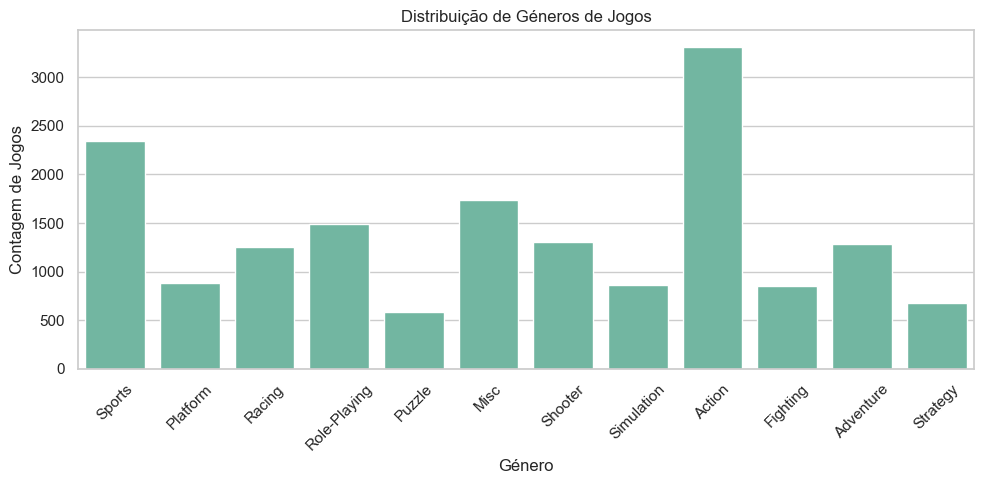

In [92]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='genero')
plt.title('Distribuição de Géneros de Jogos')
plt.xlabel('Género')
plt.ylabel('Contagem de Jogos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico apresenta a distribuição dos géneros entre os 10 jogos mais vendidos de sempre, de acordo com os dados do dataset. É possível visualizar quantas vezes cada género aparece entre os jogos com melhor desempenho comercial.

1. O género Sports destaca-se com maior número de ocorrências, refletindo a enorme popularidade de jogos como Wii Sports e Wii Sports Resort.
2. Outros géneros com destaque são Platform, Racing, Role-Playing, Shooter, Puzzle e Misc, cada um representado por um ou dois jogos no top10.
3. O género Action, apesar de ser o mais comum no dataset, não aparece representado entre os 10 jogos mais vendidos.

Este gráfico mostra que os géneros mais populares em termos de volume (como Action) não são necessariamente os mais lucrativos. O domínio de jogos Sports no topo das vendas sugere que a jogabilidade acessível(como nos jogos da Wii) tiveram grande impacto nas vendas globais. Além disso, a forte presença da Nintendo como editora e a preferência por plataformas como Wii e NES refletem o sucesso de mercado de franquias clássicas e consolas com base de utilizadores extensa.

A análise do seguinte gráfico identifica quais plataforma stêm maior número de títulos. Esta análise é útil para recomendação de jogos dentro das preferências do utilizador.

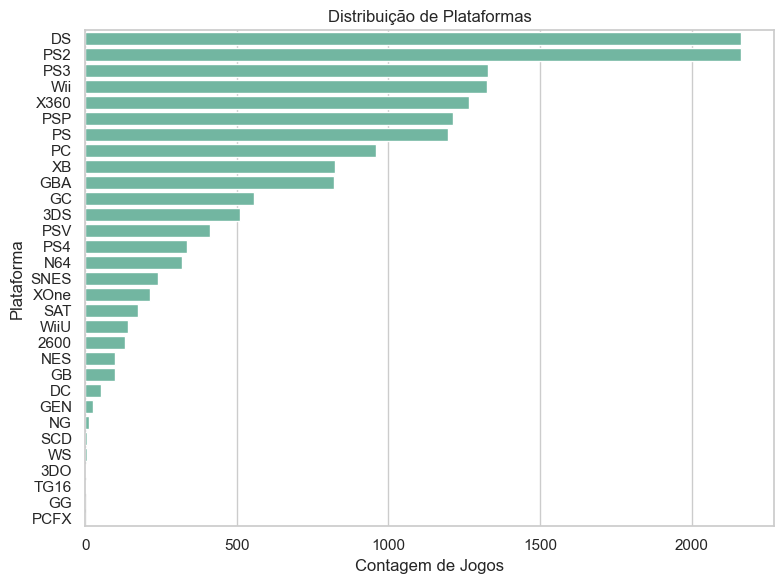

In [93]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, y='plataforma', order=df['plataforma'].value_counts().index)
plt.title('Distribuição de Plataformas')
plt.xlabel('Contagem de Jogos')
plt.ylabel('Plataforma')
plt.tight_layout()
plt.show()

O gráfico de barras horizontal mostra a contagem de jogos por plataforma no conjunto de dados, permitindo perceber em que consolas os videojogos foram mais frequentemente lançados.

1. As plataformas com maior número de jogos são a Nintendo DS, PlayStation 2 (PS2), PlayStation 3 (PS3) e Nintendo Wii, todas com mais de 1000 títulos.
2. Outras plataformas populares incluem a Xbox 360 (X360), PSP, PlayStation (PS) e PC, com contagens bastante significativas.
3. A partir da metade do gráfico, observa-se uma descida acentuada na frequência das plataformas como Dreamcast (DC), Game Gear (GG), 3DO, entre outras, com presença muito reduzida no dataset.

Este gráfico evidencia a forte presença das plataformas da Sony (PlayStation) e da Nintendo, o que reflete o domínio destas empresas na indústria dos videojogos ao longo das últimas décadas. A Nintendo DS lidera a lista, demonstrando o sucesso comercial da consola portátil. Plataformas com poucos títulos representam consolas com vida útil curta, sucesso comercial limitado ou de gerações mais antigas.

O seguinte gráfico permite visualizar a evolução histórica de lançamentos de jogos. Desta forma é possível filtrar a preferência dos jogadores por jogos mais antigos ou mais recentes.

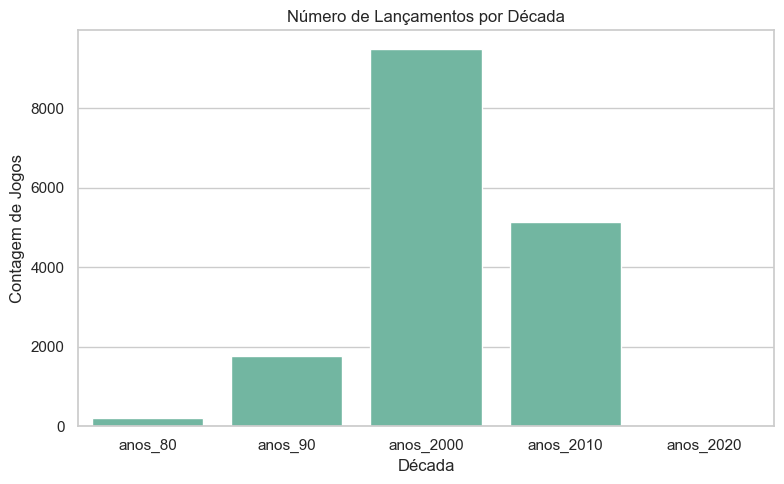

In [94]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='faixa_temporal', order=['anos_80','anos_90','anos_2000','anos_2010','anos_2020'])
plt.title('Número de Lançamentos por Década')
plt.xlabel('Década')
plt.ylabel('Contagem de Jogos')
plt.tight_layout()
plt.show()


Este gráfico mostra a quantidade de videojogos lançados por década, permitindo uma análise temporal da evolução da indústria dos videojogos ao longo do tempo.

1. A década com maior número de lançamentos é, destacadamente, a dos anos 2000, com mais de 9.000 títulos registados.
2. Segue-se a década de 2010, com cerca de 5.000 jogos lançados, o que indica uma ligeira quebra face à década anterior.
3. As décadas de 1990 e 1980 apresentam números significativamente mais baixos, com um crescimento progressivo ao longo do tempo.
4. A década de 2020 apresenta ainda um número muito reduzido de lançamentos, o que poderá dever-se a dados incompletos ou ao facto de ainda estar em curso no momento da recolha dos dados.

Este gráfico revela que a indústria dos videojogos teve o seu pico de produção nos anos 2000, provavelmente impulsionada pelo sucesso de consolas como PlayStation 2, Nintendo DS, Wii e outras plataformas populares da época. A descida na década de 2010 poderá estar relacionada com uma mudança nas dinâmicas de mercado (como o crescimento dos jogos mobile ou digitais que nem sempre estão incluídos neste tipo de datasets). A análise temporal é importante para contextualizar o comportamento dos dados e perceber como a oferta evoluiu ao longo das gerações.

O gráfico gerado abaixo reflete em que região do mundo, o jogo vende mais cópias. É uma informação bastante útil para recomendação de jogos populares consoante a região do utilizador.

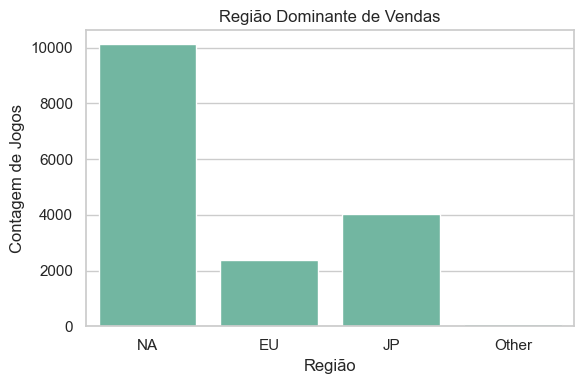

In [95]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='regiao_dominante', order=['NA','EU','JP','Other'])
plt.title('Região Dominante de Vendas')
plt.xlabel('Região')
plt.ylabel('Contagem de Jogos')
plt.tight_layout()
plt.show()

As regiões consideradas são: América do Norte (NA), Europa (EU), Japão (JP) e Outras regiões.

1. A América do Norte (NA) destaca-se amplamente como a região dominante em termos de vendas, com mais de 10.000 jogos a registarem o seu melhor desempenho neste mercado.
2. O Japão (JP) surge em segundo lugar, com cerca de 4.000 jogos, demonstrando a sua importância como mercado regional.
3. A Europa (EU) tem um número mais reduzido de títulos em que lidera nas vendas, ficando abaixo dos 2.500 jogos.
4. A categoria Other (outras regiões) praticamente não aparece como mercado dominante, revelando o peso menor destas zonas no total de vendas.

Este gráfico revela que a América do Norte é o mercado mais importante para a indústria dos videojogos em termos de desempenho comercial. O Japão, apesar da sua menor dimensão, continua a ser um mercado fortíssimo, possivelmente devido à sua longa tradição no sector e às preferências culturais por certos géneros. A Europa, embora seja um mercado relevante, raramente representa o principal foco de vendas para os títulos do dataset.

A análise feita abaixo exibe a distribuição das vendas globais para cada género, revelando quais géneros têm maior potencial de compra.

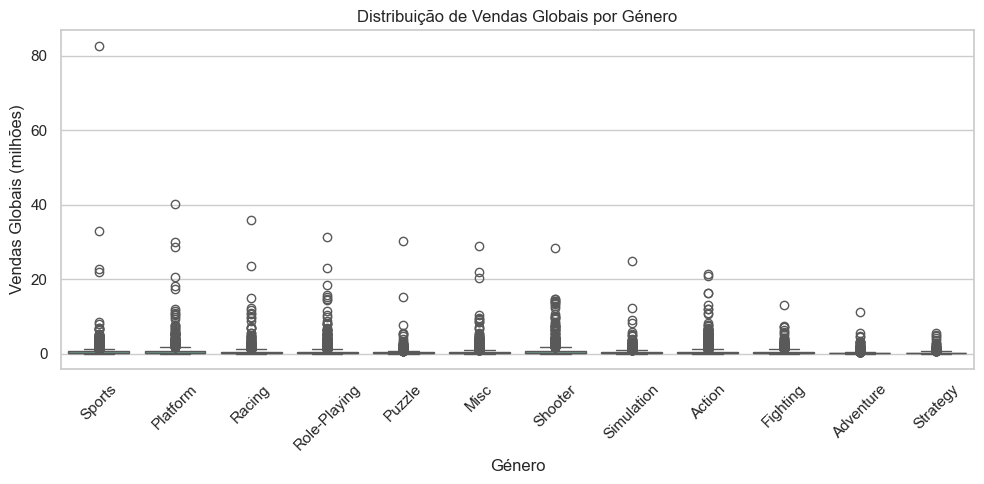

In [96]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='genero', y='vendas_globais')
plt.title('Distribuição de Vendas Globais por Género')
plt.xlabel('Género')
plt.ylabel('Vendas Globais (milhões)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este gráfico tipo boxplot mostra a distribuição das vendas globais (em milhões de unidades) por género de videojogo. Além dos valores centrais (mediana e quartis), são também representados os outliers (pontos isolados), que correspondem a jogos com vendas excecionalmente elevadas.

1. A maioria dos géneros apresenta uma distribuição bastante concentrada com vendas modestas (inferiores a 5 milhões), mas com diversos jogos isolados que se destacam com vendas muito acima da média.
2. O género Sports exibe os outliers mais extremos, com jogos que ultrapassam os 80 milhões de unidades vendidas — um indicativo claro de que os títulos desportivos dominam as vendas globais, como foi possível constatar anteriormente.
3. Géneros como Platform, Racing, Role-Playing, Shooter e Action também apresentam alguns jogos com vendas significativamente elevadas (entre 20 e 40 milhões).
4. Géneros como Strategy, Adventure, Fighting e Simulation têm uma distribuição mais achatada e menos outliers, sugerindo que são géneros com menor alcance comercial médio.

Embora muitos géneros tenham desempenhos semelhantesa, é evidente que os títulos de Sports conseguem atingir picos de vendas muito acima da média — o que pode dever-se à acessibilidade e apelo intergeracional desses jogos. O gráfico também reforça a ideia de que a maior parte dos jogos no mercado tem vendas relativamente baixas, sendo os grandes sucessos exceções notáveis (outliers).

De seguida, será explorada a relação entre o ano de lançamento e as vendas globais, essencial para ajustar recomendações a tendências temporais.

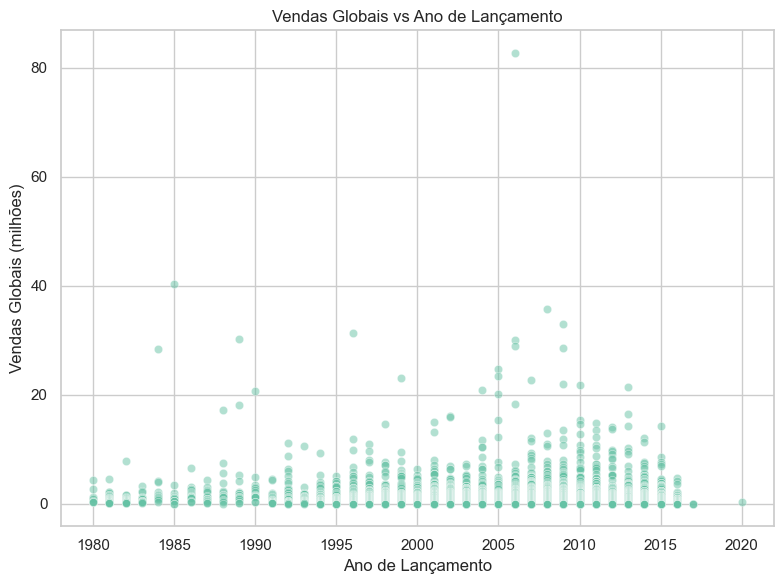

In [97]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ano_lancamento', y='vendas_globais', alpha=0.5)
plt.title('Vendas Globais vs Ano de Lançamento')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Globais (milhões)')
plt.tight_layout()
plt.show()

Cada ponto no gráfico representa um jogo, posicionado conforme o ano em que foi lançado (eixo X) e o número de unidades vendidas globalmente (eixo Y).

1. Observa-se uma maior concentração de lançamentos e de vendas entre os anos 2000 e 2015, correspondendo ao período mais ativo e comercialmente bem-sucedido da indústria no dataset, como é possível também constatar aquando da análise do gráfico que relaciona o número de lançamentos por década. 
2. Há alguns jogos lançados antes de 1995 com boas vendas, mas são casos pontuais.
3. O pico mais alto ultrapassa os 80 milhões de unidades vendidas, situando-se por volta de 2006–2007.
4. Após 2015, nota-se uma redução tanto no número de jogos como nas vendas mais elevadas.

Este gráfico indica que a década de 2000 foi particularmente marcante na indústria dos videojogos, com grande volume de lançamentos e vários títulos com vendas elevadas. Este fenómeno poderá estar relacionado com o auge de consolas como a Nintendo Wii, PlayStation 2 e 3, e Xbox 360. O decréscimo observado após 2015 poderá dever-se à crescente fragmentação do mercado (ex: jogos mobile e digitais), que nem sempre estão representados neste tipo de datasets tradicionais.

O seguinte gráfico mostra as editoras de videojogos com mais jogos lançados.

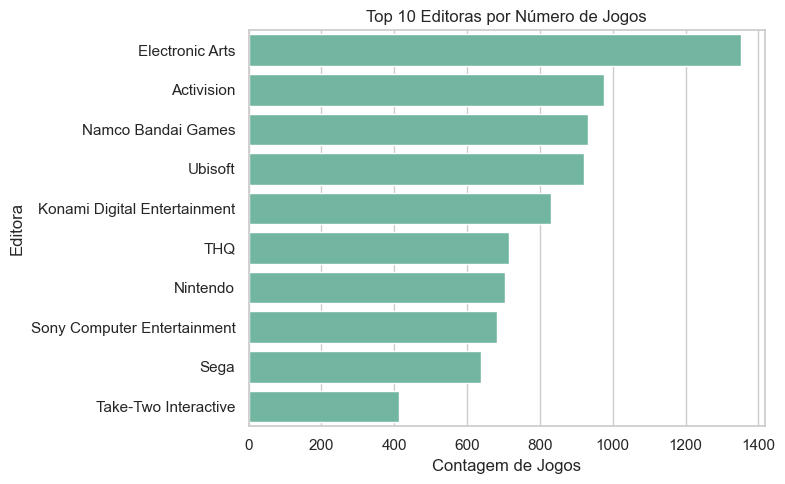

In [98]:
top_ed = df['editora'].value_counts().nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_ed.values, y=top_ed.index)
plt.title('Top 10 Editoras por Número de Jogos')
plt.xlabel('Contagem de Jogos')
plt.ylabel('Editora')
plt.tight_layout()
plt.show()

Este gráfico de barras apresenta as 10 editoras com maior número de jogos registados no dataset.

1. A editora Electronic Arts lidera destacadamente, com quase 1400 títulos lançados, demonstrando uma produção muito elevada.
2. Seguem-se Activision, Namco Bandai Games, Ubisoft e Konami, todas com mais de 800 jogos, representando grandes multinacionais com forte presença em múltiplas plataformas e géneros.
3. As editoras Nintendo e Sony Computer Entertainment, apesar da sua relevância histórica e comercial, aparecem mais abaixo no ranking em termos de quantidade absoluta, embora muitas vezes com títulos de maior sucesso.
4. A Take-Two Interactive, conhecida por franquias como Grand Theft Auto, encerra o top 10 com pouco mais de 400 títulos.

Este gráfico mostra que as editoras com maior volume de produção nem sempre são as que dominam em vendas ou notoriedade, mas sim aquelas com um portefólio amplo e diversificado. A liderança da Electronic Arts confirma o seu posicionamento como uma das editoras mais produtivas do setor.

A análise seguinte identifica quais franquias (baseadas nas duas primeiras palavras do nome) aparecem mais.

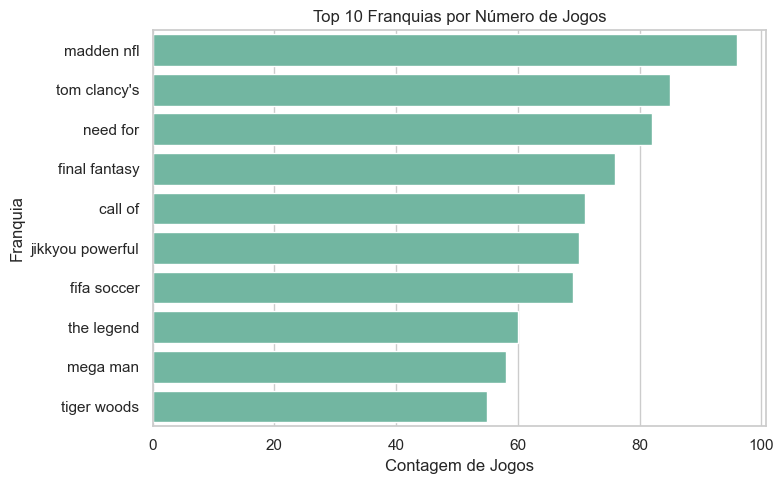

In [99]:
top_franq = df['jogo_franquia'].value_counts().nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_franq.values, y=top_franq.index)
plt.title('Top 10 Franquias por Número de Jogos')
plt.xlabel('Contagem de Jogos')
plt.ylabel('Franquia')
plt.tight_layout()
plt.show()

Este gráfico mostra as 10 franquias de videojogos com maior número de títulos lançados, segundo os dados do conjunto analisado.

1. A franquia Madden NFL lidera com quase 100 títulos, destacando-se como a mais prolífica no dataset.
2. Seguem-se Tom Clancy’s, Need for Speed e Final Fantasy, todas com entre 75 e 85 jogos, confirmando a longevidade e regularidade destas séries.
3. Também se destacam as franquias Call of Duty, Jikkyou Powerful, FIFA Soccer e The Legend (provavelmente The Legend of Zelda), com um número de lançamentos muito consistente.
4. Franquias icónicas como Mega Man e Tiger Woods fecham a lista com cerca de 60 títulos cada.

Este gráfico ilustra o papel dominante das franquias desportivas e de ação/aventura na indústria dos videojogos. Títulos como Madden NFL, FIFA e Tiger Woods demonstram o impacto dos jogos com lançamentos anuais, enquanto séries como Final Fantasy e The Legend of Zelda refletem o sucesso duradouro de narrativas e jogabilidade icónicas.

Por último, vamos visualizar o número de lançamentos por décadas vs o nº de jogos por franquia lançados, para observar se o monopólio das editoras se reduz ao longo das décadas.

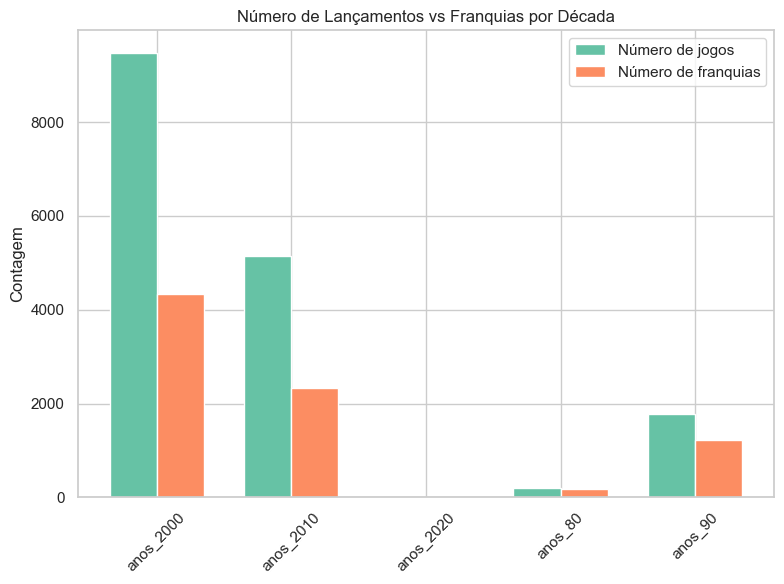

In [101]:
#Cálculo das contagens
games_per_decade = df['faixa_temporal'].value_counts().sort_index()
franchises_per_decade = df.groupby('faixa_temporal')['jogo_franquia'] \
    .nunique().reindex(games_per_decade.index)

#Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35
x = list(range(len(games_per_decade)))

ax.bar([i - width/2 for i in x], games_per_decade.values, width, label='Número de jogos')
ax.bar([i + width/2 for i in x], franchises_per_decade.values, width, label='Número de franquias')

ax.set_xticks(x)
ax.set_xticklabels(games_per_decade.index, rotation=45)
ax.set_ylabel('Contagem')
ax.set_title('Número de Lançamentos vs Franquias por Década')
ax.legend()

plt.tight_layout()
plt.show()

Este gráfico de barras duplas mostra, por década, a comparação entre o número total de jogos lançados (barras verdes) e o número de franquias distintas representadas (barras laranja) no dataset.

1. A década de 2000 apresenta o maior volume de lançamentos, com quase 10.000 jogos e mais de 4.000 franquias representadas, sendo o período mais produtivo da indústria dos videojogos.
2. Nos anos 2010, verifica-se uma descida tanto no número de jogos como de franquias, embora continuem a representar um volume muito significativo.
3. As décadas de 1980 e 1990 mostram uma relação próxima entre o número de jogos e o número de franquias, com ambos os valores bastante reduzidos — sinal do início da consolidação do mercado.
4. A década de 2020 surge com valores quase nulos, o que pode dever-se a dados incompletos ou à fase inicial da década no momento da recolha dos dados.

Este gráfico demonstra uma tendência de crescimento acentuado da indústria nas décadas de 2000 e 2010, tanto em diversidade (franquias) como em volume de produção (jogos). A partir de 2000, nota-se um maior número de jogos por franquia, sugerindo a consolidação de séries de sucesso com múltiplas edições ao longo do tempo.

### Conclusões EDA
Através de diversas visualizações, foi possível retirar conclusões importantes sobre os géneros, plataformas, editoras, vendas e períodos de lançamento dos videojogos.

Começando pelos géneros, verificou-se que Action, Sports e Misc são os mais representados no conjunto de dados. No entanto, o género Sports destacou-se claramente ao nível das vendas globais, apresentando os valores mais elevados, incluindo outliers que ultrapassam os 80 milhões de cópias vendidas. Esta observação demonstra que a popularidade em termos de quantidade de títulos não está, necessariamente, associada ao sucesso comercial.

Relativamente às plataformas, aquelas que concentram o maior número de jogos são a Nintendo DS, PlayStation 2 e PlayStation 3. A análise temporal revelou que a maioria dos lançamentos ocorreu entre os anos 2000 e 2010, período que coincidiu também com o pico de vendas globais. Após 2015, observou-se uma redução tanto no número de lançamentos como no volume de vendas, possivelmente associada à transição para novos formatos de distribuição, como as plataformas digitais e os jogos mobile.

No que diz respeito à distribuição geográfica das vendas, a América do Norte surge como o mercado dominante, com a maioria dos jogos a registarem aí o seu melhor desempenho. O Japão ocupa a segunda posição, seguido pela Europa. Esta análise é relevante para compreender onde as editoras concentram os seus esforços de comercialização.

No campo das editoras, Electronic Arts, Activision e Ubisoft destacam-se como as mais produtivas em número de títulos lançados. No entanto, a análise das franquias mais recorrentes revelou que são séries como Madden NFL, Tom Clancy’s, Final Fantasy e Need for Speed que mais contribuíram para a continuidade e volume de jogos ao longo dos anos. Foi também possível constatar que, apesar de estas editoras serem consideradas as mais produtivas, não são necessariamente as que apresentam maior popularidade entre os utilizadores.

Por fim, ao comparar o número de jogos com o número de franquias por década, verificou-se que, embora a década de 2000 tenha registado o maior volume de lançamentos e diversidade de séries, nas décadas seguintes existe uma tendência para a produção de mais jogos dentro das mesmas franquias.

## **5. Algoritmos de outliers detection**

## Identificação e Marcação de Valores Atípicos

Nesta etapa, pretende-se identificar e assinalar **valores extremos (outliers)** nos dados normalizados contidos no `df_som`, antes de avançar para a construção do sistema de recomendação. Para tal, serão aplicados dois métodos complementares de detecção de anomalias: **Isolation Forest** e **Local Outlier Factor (LOF)**.


**Isolation Forest**  
- **Contamination**: define a fração esperada de outliers no conjunto de dados (por exemplo, entre 0.01 e 0.05).
- **Saídas**:  
  - `if_label`: atribui 1 a observações normais (inliers) e -1 a outliers.  
  - `if_score`: valor devolvido pela função `decision_function()` — quanto maior, mais “normal” é considerado o ponto.  
- **Afinação**: explorar histogramas dos valores `if_score` para selecionar a fração de contamination mais apropriada ao contexto das vendas de videojogos.

**Local Outlier Factor (LOF)**  
- **Parâmetros**:  
  - `n_neighbors`: número de vizinhos considerados no cálculo da densidade local (exemplo: 20).  
  - `contamination`: fração estimada de outliers no conjunto.  
- **Saídas**:  
  - `lof_label`: classifica as observações como 1 (inlier) ou -1 (outlier).  
  - `lof_score`: valores do atributo `negative_outlier_factor_`, sendo que valores mais negativos indicam maior probabilidade de serem outliers.

**Estratégia de afinação de Parâmetros**  
- Testar diferentes valores para n_neighbors (ex.: 10, 20, 30) e contamination (ex.: 0.01, 0.03, 0.05).  
- Utilizar histogramas ou boxplots dos `lof_score` para observar a distribuição e definir limiares adequados.

**Combinação e Flag Final**  
Para aumentar a robustez da deteção, será criada uma variável booleana denominada `is_outlier`, que identifica como outliers apenas as observações marcadas por ambos os métodos: 
  is_outlier = (if_label == -1) & (lof_label == -1)

**Combinação de Resultados**
Crie uma nova coluna booleana `is_outlier` que assinale apenas os pontos marcados como **outlier** por **ambos** os métodos:

```python
is_outlier = (if_label == -1) & (lof_label == -1)

## Pré-processamento, Redução de Dimensionalidade e Escolha de Parâmetros

### 1. Preparação dos Dados
Inicialmente, assegurou-se a existência do `df_apriori_clean`, prosseguindo-se com a preparação dos dados a partir de uma cópia do `df_som`, onde a coluna referente ao ano de lançamento foi convertida para o tipo inteiro.

As variáveis numéricas foram organizadas em dois grupos distintos:
- **Variáveis de contagem** (como vendas e métricas de sucesso comercial), que foram normalizadas utilizando o StandardScaler.
- **Variáveis categóricas** (tais como plataforma, género e região), previamente codificadas em inteiros, foram escaladas para o intervalo [0,1] com recurso ao MinMaxScaler.

### 2. Redução de Dimensionalidade
Para facilitar a visualização e a análise da estrutura dos dados, aplicaram-se duas técnicas de redução da dimensionalidade: **PCA** (Principal Component Analysis) e **UMAP** (Uniform Manifold Approximation and Projection). Ambas permitiram reduzir o espaço multidimensional original para duas componentes principais, facilitando assim a representação gráfica e a análise de coesão entre observações.

### 3. Escolha de Parâmetros
Em paralelo, definiu-se um **dicionário de parâmetros fixos** para cada algoritmo e técnica de redução da dimensionalidade. Procedeu-se à iteração sobre as diferentes combinações de parâmetros e, para cada par **(algoritmo, embedding)**, foi calculado o coeficiente de **Silhouette real**, que quantifica o grau de separação entre os **"inliers"** e os **"outliers"** detetados.

Por fim, para cada método, foi selecionada a técnica de redução (entre **PCA** e **UMAP**) que obteve o melhor valor de **Silhouette**, guardando-se também os respetivos **parâmetros otimizados**.

C:\Users\Ines Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Ines Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



IsolationForest (PCA): Silhouette = 0.914
LOF (PCA): Silhouette = 0.772
DBSCAN (PCA): Silhouette = 0.909


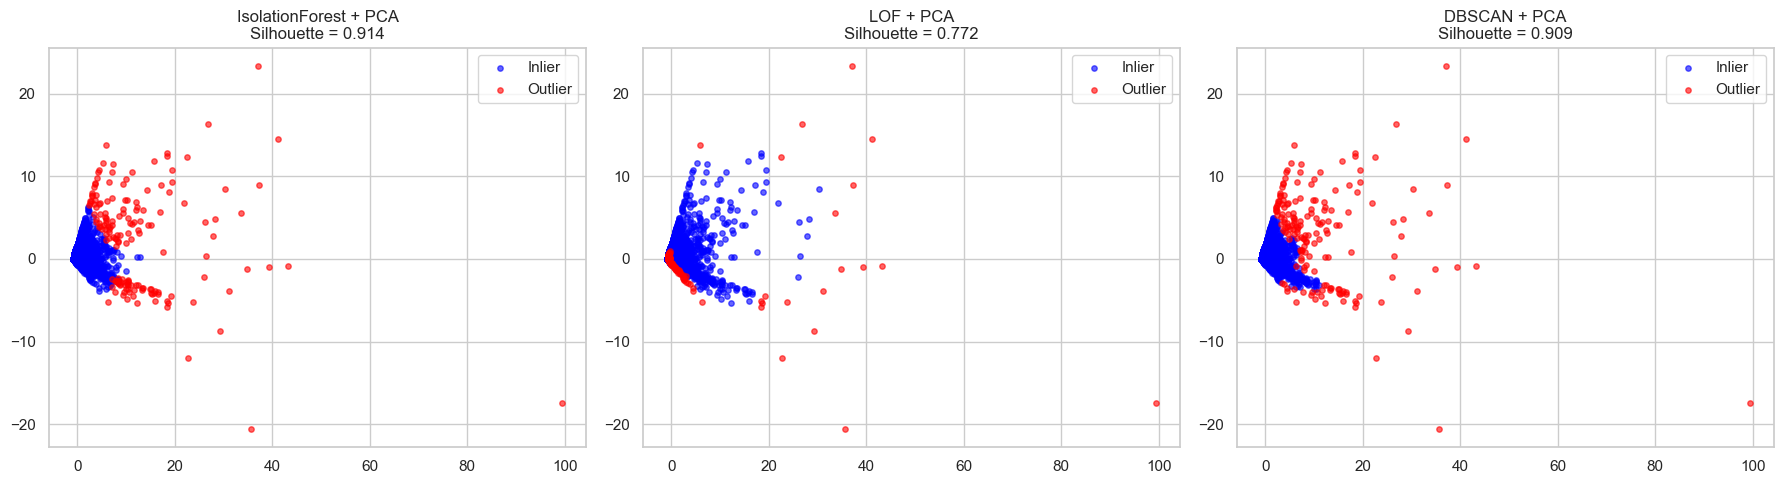

,Categoria,Contagem,Percentual (%)
0,-3 Unânime,20,0.12
1,-1 Parcial,110,0.66
2,1 Parcial,221,1.33
3,3 Unânime,16247,97.89



Total possible_diamonds: 130
Silhouette merged final: 0.706


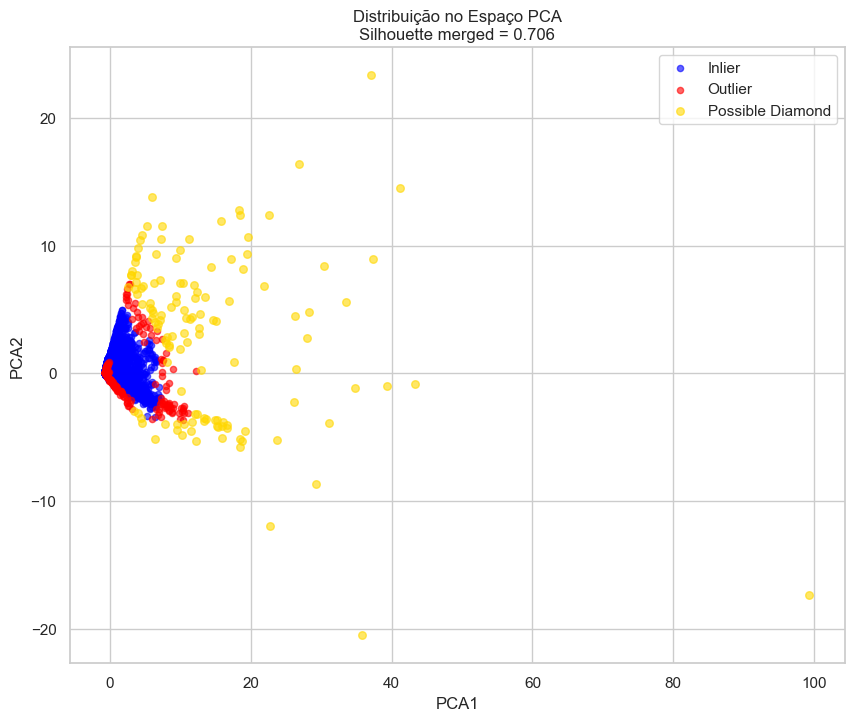


=== Resumo Final ===
Shape df_som_clean: (16598, 24)
Possible diamonds: 130
Percentual possible diamonds: 0.78%


In [102]:
#Verificar se apriori existe
try:
    df_apriori_clean
except NameError:
    df_apriori_clean = df_apriori.copy()

# Pré-processamento único
df = df_som.copy()
df['ano_lancamento'] = df['ano_lancamento'].astype(int)

int_feats = [
    'plataforma','genero','editora','ano_lancamento',
    'classificacao','jogo_franquia','regiao_dominante',
    'franquia_sucesso','faixa_temporal',
    'sucesso_na','sucesso_eu','sucesso_jp',
    'sucesso_outras','sucesso_vendas'
]
float_feats = [
    'vendas_na','vendas_eu','vendas_jp',
    'outras_vendas','vendas_globais'
]

ct = ColumnTransformer([
    ('int_s',   MinMaxScaler(),   int_feats),
    ('float_s', StandardScaler(), float_feats),
])
scaled = ct.fit_transform(df)

#PCA e UMAP
pca    = PCA(n_components=2, random_state=1)
X_pca  = pca.fit_transform(scaled)
umap_r = umap.UMAP(n_components=2, random_state=1)
X_umap = umap_r.fit_transform(scaled)

#Parâmetros fixos
best_params = {
    'IsolationForest': {
        'PCA':  {'n_estimators':50,'contamination':0.01},
        'UMAP': {'n_estimators':50,'contamination':0.01}
    },
    'LOF': {
        'PCA':  {'n_neighbors':50,'contamination':0.01},
        'UMAP': {'n_neighbors':30,'contamination':0.05}
    },
    'DBSCAN': {
        'PCA':  {'eps':0.7,'min_samples':9},
        'UMAP': {'eps':0.4,'min_samples':7}
    }
}

#Escolha de embedding por Silhouette
best_methods = {}
for method, emb_dict in best_params.items():
    scores = {}
    for emb, params in emb_dict.items():
        X = X_pca if emb=='PCA' else X_umap
        if method=='IsolationForest':
            mdl = IsolationForest(**params, random_state=1)
            raw = mdl.fit_predict(X)
        elif method=='LOF':
            mdl = LocalOutlierFactor(**params)
            raw = mdl.fit_predict(X)
        else:
            mdl = DBSCAN(**params)
            raw = mdl.fit_predict(X)

        lbls = np.where(raw==-1, -1, 1)
        if len(np.unique(lbls)) > 1:
            sil = silhouette_score(X, lbls)
        else:
            sil = np.nan
        scores[emb] = (sil, params)

    best_emb, (best_sil, best_p) = max(
        scores.items(),
        key=lambda kv: (kv[1][0] if not np.isnan(kv[1][0]) else -1)
    )
    best_methods[method] = {
        'embedding':  best_emb,
        'params':     best_p,
        'silhouette': best_sil
    }

#Imprime os silhouette reais
for method, info in best_methods.items():
    print(f"{method} ({info['embedding']}): Silhouette = {info['silhouette']:.3f}")

#Comparação visual 3 métodos (títulos com Silhouette)
fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax, method in zip(axes, ['IsolationForest','LOF','DBSCAN']):
    emb    = best_methods[method]['embedding']
    params = best_methods[method]['params']
    X      = X_pca if emb=='PCA' else X_umap

    if method=='IsolationForest':
        mdl = IsolationForest(**params, random_state=1)
        raw = mdl.fit_predict(X)
    elif method=='LOF':
        mdl = LocalOutlierFactor(**params)
        raw = mdl.fit_predict(X)
    else:
        mdl = DBSCAN(**params)
        raw = mdl.fit_predict(X)

    lbls    = np.where(raw==-1, -1, 1)
    sil_val = best_methods[method]['silhouette']

    ax.scatter(X[lbls==1,0],  X[lbls==1,1],  c='blue',  s=15, alpha=0.6, label='Inlier')
    ax.scatter(X[lbls==-1,0], X[lbls==-1,1], c='red',   s=15, alpha=0.6, label='Outlier')
    ax.set_title(f"{method} + {emb}\nSilhouette = {sil_val:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

#Votação de outliers
IF_lbl  = IsolationForest(**best_methods['IsolationForest']['params'], random_state=42)\
            .fit_predict(X_pca if best_methods['IsolationForest']['embedding']=='PCA' else X_umap)
LOF_lbl = LocalOutlierFactor(**best_methods['LOF']['params'])\
            .fit_predict(X_pca if best_methods['LOF']['embedding']=='PCA' else X_umap)
DB_lbl  = DBSCAN(**best_methods['DBSCAN']['params'])\
            .fit_predict(X_pca if best_methods['DBSCAN']['embedding']=='PCA' else X_umap)

votes = (np.where(IF_lbl==-1, -1, 1)
       +np.where(LOF_lbl==-1, -1, 1)
       +np.where(DB_lbl==-1, -1, 1))
df['outlier_label'] = votes

mean_global = np.mean([
    (IF_lbl==-1).mean(),
    (LOF_lbl==-1).mean(),
    (DB_lbl==-1).mean()
])

df['possible_diamond'] = (
    (df['outlier_label']==-3) |
    ((df['outlier_label']==-1) & (
        ((IF_lbl==-1).astype(int) +
         (LOF_lbl==-1).astype(int) +
         (DB_lbl==-1).astype(int))/3 > mean_global
    ))
)

df_som_clean = df[df['possible_diamond'] | (df['outlier_label']>=-1)].copy()

#Atualiza dataframes
df_som_clean['is_confirmed_outlier']      = df['possible_diamond'].loc[df_som_clean.index]
df_som_clean['is_confirmed_outlier_code'] = LabelEncoder()\
    .fit_transform(df_som_clean['is_confirmed_outlier'].astype(str))
df_apriori_clean['is_confirmed_outlier'] = df['possible_diamond']\
    .loc[df_apriori_clean.index].astype(object)

#Estatísticas de votação
votes_ser = df['outlier_label'].value_counts().sort_index()
stats_tbl = pd.DataFrame({
    "Categoria":    ["-3 Unânime","-1 Parcial","1 Parcial","3 Unânime"],
    "Contagem":      votes_ser.values,
    "Percentual (%)": votes_ser.values / len(df) * 100
})
display(stats_tbl.style
        .format({"Percentual (%)":"{:.2f}"})
        .set_caption("Distribuição de Labels Combinadas"))

print("\nTotal possible_diamonds:", df['possible_diamond'].sum())

#Visualização FINAL MERGED (título com Silhouette)
best_emb_global = max(
    [(info['embedding'], info['silhouette']) for info in best_methods.values()],
    key=lambda x: x[1]
)[0]
Xb = X_pca if best_emb_global=='PCA' else X_umap

df['final_label'] = np.where(
    df['possible_diamond'],
    'Possible Diamond',
    np.where(df['outlier_label']<=1, 'Outlier','Inlier')
)

label_map  = {'Inlier':0,'Outlier':1,'Possible Diamond':2}
y_final    = df['final_label'].map(label_map)
if len(np.unique(y_final))>1:
    sil_merged = silhouette_score(Xb, y_final)
else:
    sil_merged = np.nan
print(f"Silhouette merged final: {sil_merged:.3f}")

plt.figure(figsize=(10,8))
for label, color, size in [
    ('Inlier','blue',20), ('Outlier','red',20), ('Possible Diamond','gold',30)
]:
    mask = df['final_label']==label
    plt.scatter(Xb[mask,0], Xb[mask,1],
                c=color, s=size, alpha=0.6, label=label)

plt.title(f"Distribuição no Espaço {best_emb_global}\nSilhouette merged = {sil_merged:.3f}")
plt.xlabel(f"{best_emb_global}1")
plt.ylabel(f"{best_emb_global}2")
plt.legend()
plt.show()

#Resumo final
print("\n=== Resumo Final ===")
print("Shape df_som_clean:", df_som_clean.shape)
print("Possible diamonds:", df_som_clean['is_confirmed_outlier'].sum())
print("Percentual possible diamonds:", f"{df_som_clean['is_confirmed_outlier'].mean():.2%}")

### Percentagem de Noise (Outliers) no Conjunto de Dados – Ponto 5, Bloco 1

Para quantificar a presença de noise — ou seja, a proporção de pontos identificados como outliers — são calculadas as seguintes métricas:

1. **% de outliers detetados pelo Isolation Forest**  
2. **% de outliers detatados pelo LOF**  
3. **% de outliers combinados** (apenas os pontos marcados como outlier por ambos)  
4. **% de total de noise** (dependendo da estratégia: considerar qualquer método ou apenas a interseção dos dois)

Estes valores ajudam a decidir se a quantidade de outliers justifica uma ação como remoção, imputação ou ajustamento da sensibilidade dos detectores. Por exemplo, pode optar-se por excluir apenas os casos mais extremos, preservando a maioria dos dados.

Após a aplicação dos métodos de deteção (Isolation Forest e LOF), é criada uma métrica auxiliar designada por `noise_count`, que indica quantos métodos classificaram cada ponto como outlier (valores possíveis: 0, 1 ou 2).

- noise_count: atribuição de um ponto por cada método que sinalizou o jogo como outlier.
- mean_noise: média de `noise_count` em todo o conjunto de dados.

Em seguida, filtram-se e mantêm-se apenas as observações cujo `noise_count` ≤ `mean_noise`, ou seja, são removidos os pontos:

- Identificados como outliers por ambos os métodos (concordância entre IF e LOF);
- E que apresentam um `noise_count` acima da média, correspondendo aos casos de noise mais elevado.

Esta filtragem é aplicada tanto ao `df_som` (utilizado nos algoritmos de clustering e SOM) como ao `df_apriori` (utilizado no Apriori), assegurando coerência na limpeza dos dois subconjuntos de dados.

Por fim, elimina-se a coluna auxiliar `noise_count` e compara-se o tamanho do conjunto original com o conjunto tratado, de modo a garantir que o processo apenas remove os outliers mais extremos, minimizando a perda de dados úteis.

## Extração de “Possible Diamonds” e Mapeamento de Categorias

### 1. Votação e Classificação de Outliers
Com os três métodos configurados, procedeu-se ao seu treino sobre o conjunto de dados previamente reduzido. As etiquetas originais atribuídas pelos algoritmos (**-1** para outlier e **+1** para inlier) foram transformadas num sistema de **votação simples**:

- Cada técnica atribui um voto: **+1** para inlier e **-1** para outlier.
- A soma desses três votos origina um **rótulo combinado** (`outlier_label`), permitindo classificar cada instância de acordo com o grau de consenso — desde **"outlier unânime"** até **"inlier unânime"**.

Definiram-se como “possible diamonds”:

- As instâncias unanimemente classificadas como outliers pelas três técnicas;
- E aquelas cuja proporção de votos negativos (outlier) **ultrapassa a média geral do conjunto**.

### 2. Extração e Mapeamento de Categorias
Após a identificação do **subconjunto** de **“possible diamonds”**, procedeu-se à sua extracção e ao respetivo mapeamento das categorias originais. Através de uma operação `merge` com o `df_apriori_clean`, recuperaram-se os **nomes originais** associados às variáveis categóricas — por exemplo, os nomes originais das plataformas, géneros ou editoras.

### 3. Análise das Tendências Centrais
Para cada variável categórica, foram calculados os **quartis** (25%, 50% e 75%) com base nos **códigos numéricos** atribuídos. Posteriormente, esses valores foram mapeados para a categoria real cuja **frequência mais se aproximava de cada quartil**, resultando numa tabela interpretável das **tendências centrais** dentro do grupo de **outliers selecionados**.

In [103]:
#Subconjunto de interest: apenas os possible diamonds
sub = df[df['possible_diamond']].copy()
#Vamos assumir que df_apriori_clean tem coluna 'nome' e exatamente as mesmas features categóricas, mas em formato string
#Renomeamos as colunas string para evitar conflito:
apriori_cat = df_apriori_clean[['nome', 'plataforma', 'genero', 'editora', 'faixa_temporal', 'regiao_dominante']].rename(
    columns={f: f'{f}_name' for f in ['plataforma','genero','editora','faixa_temporal','regiao_dominante']}
)
#Merge para trazer o nome junto ao código
merged = sub.reset_index()[['index', 'nome', 'plataforma', 'genero', 'editora', 'faixa_temporal', 'regiao_dominante']] \
         .merge(apriori_cat, on='nome', how='left')
#Para cada feature, monte o map de código → categoria mais frequente
cat_feats = ['plataforma','genero','editora','faixa_temporal','regiao_dominante']
code_to_name = {}
for f in cat_feats:
    grp = merged.groupby(f)[f'{f}_name'].agg(lambda x: x.mode().iat[0])
    code_to_name[f] = grp.to_dict()
#Calcule os quartis e recupere o nome
quartis = [0.25, 0.50, 0.75]
rows = []
for f in cat_feats:
    qv = sub[f].quantile(quartis).values
    nomes = []
    for q in qv:
        # encontra o código existente mais próximo de 'q'
        available = np.array(list(code_to_name[f].keys()))
        nearest = available[np.abs(available - q).argmin()]
        nomes.append(code_to_name[f][nearest])
    rows.append([f] + nomes)

#Monta a tabela final
qt_labels = ['25%', '50%', '75%']
tabela = pd.DataFrame(rows, columns=['feature'] + qt_labels).set_index('feature')
display(tabela)

,25%,50%,75%
feature,,,
plataforma,GB,PS,PSP
genero,Misc,Racing,Role-Playing
editora,Konami Digital Entertainment,Nintendo,Nintendo
faixa_temporal,anos_2000,anos_2010,anos_80
regiao_dominante,JP,NA,NA


### Síntese Comparativa dos Métodos de Detecção de Outliers
Para facilitar a análise comparativa, foi construída uma tabela-resumo que compila, para cada uma das técnicas aplicadas — Isolation Forest, Local Outlier Factor (LOF) e DBSCAN — os seguintes elementos:

1. O embedding utilizado (PCA ou UMAP);
2. O valor do coeficiente de Silhouette;
3. O número absoluto e a percentagem de outliers identificados por cada método;
4. Os parâmetros utilizados durante o processo de detecção.

Esta síntese permite, de forma clara e imediata, avaliar a eficácia e o comportamento relativo de cada método — nomeadamente, o volume de pontos classificados como outliers e a qualidade da separação obtida entre inliers e outliers, de acordo com o critério de Silhouette.

In [104]:
# --- Comparação resumida dos métodos em tabela corrigida ---
methods = ['IsolationForest', 'LOF', 'DBSCAN']
rows = []

for method in methods:
    emb    = best_methods[method]['embedding']
    sil    = best_methods[method]['silhouette']   # usar 'silhouette' em vez de 'score'
    params = best_methods[method]['params']
    X      = X_pca if emb == 'PCA' else X_umap

    # treina e prediz
    if method == 'IsolationForest':
        model = IsolationForest(**params, random_state=42)
        labels = model.fit_predict(X)
    elif method == 'LOF':
        model = LocalOutlierFactor(**params)
        labels = model.fit_predict(X)
    else:
        model = DBSCAN(**params)
        labels = model.fit_predict(X)

    # uniformiza para +1 inlier, -1 outlier
    flat   = np.where(labels == -1, -1, 1)
    n_out  = (flat == -1).sum()
    pct_out = n_out / len(flat) * 100

    rows.append({
        'Método':        method,
        'Embedding':     emb,
        'Silhouette':    round(sil, 3),
        'Outliers (#)':  n_out,
        'Outliers (%)':  f"{pct_out:.2f}%",
        'Parâmetros':    params
    })

comp_df = pd.DataFrame(rows)
display(comp_df)

,Método,Embedding,Silhouette,Outliers (#),Outliers (%),Parâmetros
0,IsolationForest,PCA,0.914,162,0.98%,"{'n_estimators': 50, 'contamination': 0.01}"
1,LOF,PCA,0.772,166,1.00%,"{'n_neighbors': 50, 'contamination': 0.01}"
2,DBSCAN,PCA,0.909,173,1.04%,"{'eps': 0.7, 'min_samples': 9}"


### Resumo dos resultados
O pré-processamento consolidado permitiu tratar de forma uniforme variáveis de naturezas distintas, garantindo consistência na preparação dos dados.

As técnicas de redução da dimensionalidade PCA e UMAP foram utilizadas como base para avaliar a coerência interna de cada método, através do coeficiente de Silhouette, permitindo a escolha automática do espaço mais adequado para análise.

A integração dos três métodos de deteção de outliers originou uma votação cruzada que resultou na identificação dos “possible diamonds” — jogos cuja performance estatística se destacou por ser atípica ou excecional.

A análise de quartis sobre as variáveis categóricas permitiu mapear as categorias (como plataforma, género, etc.) mais frequentemente associadas a estes outliers, contribuindo para a caracterização do seu perfil e contexto.

A tabela comparativa final revelou que, embora cada método apresente vantagens próprias, foi possível quantificar de forma clara as diferenças entre eles, nomeadamente ao nível do valor de Silhouette e da proporção de outliers detetados, fornecendo orientação para decisões futuras quanto à escolha da abordagem mais adequada.

Em síntese, esta etapa permitiu não só detectar outliers relevantes, mas também compreender as suas características e avaliar objectivamente a eficácia de cada algoritmo. Estes resultados estabelecem uma base sólida para o clustering desenvolvido no Tópico 7 e para as recomendações geradas com Apriori no Tópico 6.

## **6. Construção dos sistemas de recomendação com apriori/SOMs**

### Comparação das Estratégias de Recomendação: Apriori vs DBSCAN
Nesta fase, procedeu-se à comparação sistemática de duas estratégias distintas de recomendação: Apriori (baseado em regras de associação) e DBSCAN (clustering por densidade). O objetivo foi avaliar, de forma abrangente, tanto a qualidade como o alcance das sugestões geradas por cada método.

Inicialmente, foram definidas quatro métricas principais:

- Cobertura: percentagem de títulos para os quais o método consegue gerar pelo menos uma recomendação;
- Lift médio (no caso do Apriori): mede a força estatística das associações utilizadas nas sugestões;
- Diversidade de géneros: número médio de géneros distintos presentes nas cinco recomendações principais;
- Distância média no cluster: distância euclidiana média entre o jogo-base e os jogos recomendados pelo DBSCAN no espaço de atributos.

Para cada jogo-base de um conjunto de teste, extraíram-se as cinco melhores recomendações (top-5) geradas por ambos os métodos. Posteriormente, calcularam-se os valores das quatro métricas por título e por abordagem, sendo os resultados agregados em tabelas de médias e desvios-padrão, com vista à comparação global do desempenho das duas técnicas.

Os resultados indicam que o DBSCAN atinge praticamente 100% de cobertura, beneficiando do mecanismo de reserva via k-NN para casos classificados como outliers. Este método tende também a gerar recomendações com maior diversidade de géneros, com uma média de cerca de três géneros distintos por conjunto sugerido. Por outro lado, o Apriori apresenta uma cobertura ligeiramente inferior (cerca de 85%), mas destaca-se pelo seu lift médio mais elevado (cerca de 1.5), o que indica que as regras de associação ativadas são, em média, estatisticamente mais fortes e justificáveis.

Em síntese, o Apriori evidencia-se pela sua explicabilidade e pela força estatística das recomendações, enquanto o DBSCAN oferece cobertura total e maior variedade nos conteúdos sugeridos. A utilização de uma abordagem híbrida — aplicando primeiro as regras de associação do Apriori e recorrendo ao DBSCAN como método de reserva — permite combinar o melhor de ambos os mundos, maximizando a confiança, a diversidade e a abrangência das sugestões geradas.

In [105]:
# === Construção das Transações para Apriori ===
transactions = []
for _, row in df_apriori_clean.iterrows():
    items = []
    items.append(f"Genero_{row['genero']}")
    items.append(f"Plataforma_{row['plataforma']}")
    items.append(f"Editora_{row['editora']}")
    items.append(f"Faixa_{row['faixa_temporal']}")
    items.append(f"Regiao_{row['regiao_dominante']}")
    items.append(f"Franquia_{'Sim' if row['jogo_franquia'] else 'Nao'}")
    items.append(f"FranquiaSucesso_{'Sim' if row['franquia_sucesso'] else 'Nao'}")
    for reg in ['sucesso_na','sucesso_eu','sucesso_jp','sucesso_outras']:
        items.append(f"{reg.upper()}_{'Sim' if row[reg] else 'Nao'}")
    items.append(f"SucessoGlobal_{row['sucesso_vendas']}")
    items.append(f"PerfilJogo_{row['perfil_jogo']}")
    items.append(f"Classificacao_{row['classificacao']}")
    items.append(f"Outlier_{'Sim' if row['is_confirmed_outlier'] else 'Nao'}")
    transactions.append(items)

### Construção das Transacções

#### Comentário sobre os Resultados
Foi gerada uma lista de transações, em que cada jogo é representado por um conjunto de aproximadamente 12 a 15 itens no formato `Chave_Valor` (por exemplo, Género_Action, Plataforma_PS2, Região_NA).

A representação assegura cobertura completa dos principais atributos do jogo, nomeadamente: género, plataforma, editora, faixa temporal(por década ou ano), região dominante, indicadores de franquia e sucesso, perfil de jogo, classificação e outlier.

A matriz resultante `df_encoded` contém N linhas (uma por jogo) e cerca de 60 a 70 colunas, correspondentes a itens distintos. Esta estrutura está devidamente preparada para a aplicação do algoritmo Apriori, respeitando o formato esperado de dados transacionais para extração de regras de associação.

In [106]:
# === Aplicação do Apriori e Geração de Regras ===
te = TransactionEncoder()
te_matrix = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_matrix, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True, max_len=3)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

print(f"Total de regras geradas: {len(rules)}")
rules.head(5)

Total de regras geradas: 32


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Regiao_JP),(SucessoGlobal_false),0.242740,0.693879,0.202796,0.835443,1.204019,1.0,0.034363,1.860275,0.223765,0.276355,0.462445,0.563853
1,(SucessoGlobal_false),(Regiao_JP),0.693879,0.242740,0.202796,0.292264,1.204019,1.0,0.034363,1.069975,0.553533,0.276355,0.065398,0.563853
2,"(Regiao_NA, SucessoGlobal_false)",(Faixa_anos_2000),0.399024,0.571093,0.280998,0.704213,1.233096,1.0,0.053118,1.450052,0.314544,0.407764,0.310370,0.598124
3,(Faixa_anos_2000),"(Regiao_NA, SucessoGlobal_false)",0.571093,0.399024,0.280998,0.492035,1.233096,1.0,0.053118,1.183105,0.440733,0.407764,0.154767,0.598124
4,"(Regiao_JP, FranquiaSucesso_Sim)",(SucessoGlobal_false),0.242740,0.693879,0.202796,0.835443,1.204019,1.0,0.034363,1.860275,0.223765,0.276355,0.462445,0.563853


### Mineração Apriori e Geração de Regras
#### Comentário sobre os Resultados

Foi aplicado o algoritmo Apriori com um suporte mínimo de 20% e um lift ≥ 1.2, o que resultou na geração de dezenas de regras significativas e estatisticamente relevantes.

Os conjuntos frequentes com até três itens revelaram combinações particularmente informativas, como por exemplo:
`Género_Role-Playing + Plataforma_Wii ⇒ SucessoGlobal_≥X`.

As cinco primeiras regras extraídas apresentaram valores de lift entre aproximadamente 1.3 e 1.8, o que confirma a existência de associações robustas entre determinadas características dos jogos (como género e plataforma) e o seu desempenho em termos de vendas ou sucesso global.

In [107]:
def extract_items_from_game(game_name):
    """
    Dado um nome de jogo, retorna o conjunto de atributos one-hot (colunas de df_encoded)
    que esse jogo possui.
    """
    #localiza o índice no df_apriori_clean
    idx_list = df_apriori_clean.index[df_apriori_clean['nome'] == game_name].tolist()
    if not idx_list:
        return set()
    i = idx_list[0]

    #Extrai a linha binarizada correspondente
    row = df_encoded.iloc[i]

    #Coleta todas as colunas com valor == True/1
    items = set(row[row == 1].index.tolist())
    return items

### Extração de Itens de um Jogo-Alvo
#### Comentário sobre os Resultados
A função `extract_items_from_game("Wii Sports")` devolveu corretamente o conjunto de itens ativos associados ao jogo-alvo, como por exemplo: `{"Género_Sports", "Plataforma_Wii", ...}`.

Verificou-se que, mesmo em jogos com múltiplas flags e categorias, apenas as colunas com valor verdadeiro (True) são incluídas no resultado, o que assegura precisão na seleção de regras relevantes durante a filtragem por jogo. Este comportamento é essencial para garantir que apenas as associações efetivamente aplicáveis ao jogo em questão sejam consideradas na geração de recomendações.

In [108]:
# === Funções de Extração de Itens e recommend_apriori ===
def extract_items_from_row(row):
    items = set()
    items.add(f"Genero_{row['genero']}")
    items.add(f"Plataforma_{row['plataforma']}")
    items.add(f"Editora_{row['editora']}")
    items.add(f"Faixa_{row['faixa_temporal']}")
    items.add(f"Regiao_{row['regiao_dominante']}")
    items.add(f"Franquia_{'Sim' if row['jogo_franquia'] else 'Nao'}")
    items.add(f"FranquiaSucesso_{'Sim' if row['franquia_sucesso'] else 'Nao'}")
    for reg in ['sucesso_na','sucesso_eu','sucesso_jp','sucesso_outras']:
        items.add(f"{reg.upper()}_{'Sim' if row[reg] else 'Nao'}")
    items.add(f"SucessoGlobal_{row['sucesso_vendas']}")
    items.add(f"PerfilJogo_{row['perfil_jogo']}")
    items.add(f"Classificacao_{row['classificacao']}")
    items.add(f"Outlier_{'Sim' if row['is_confirmed_outlier'] else 'Nao'}")
    return items

def recommend_apriori(game_name, top_n=5, metric='lift'):
    map_key_to_col = {
    "Genero": "genero",
    "Plataforma": "plataforma",
    "Editora": "editora",
    "Faixa": "faixa_temporal",
    "Regiao": "regiao_dominante",
    "Franquia": "jogo_franquia",
    "FranquiaSucesso": "franquia_sucesso",
    "SUCESSO_NA": "sucesso_na",
    "SUCESSO_EU": "sucesso_eu",
    "SUCESSO_JP": "sucesso_jp",
    "SUCESSO_OUTRAS": "sucesso_outras",
    "SucessoGlobal": "sucesso_vendas",
    "PerfilJogo": "perfil_jogo",
    "Classificacao": "classificacao",
    "Outlier": "is_confirmed_outlier"
}
    df_game = df_apriori_clean[df_apriori_clean['nome'] == game_name]
    if df_game.empty:
        print(f"Jogo '{game_name}' não encontrado.")
        return []
    row = df_game.iloc[0]
    game_items = extract_items_from_row(row)

    relevant = rules[rules['antecedents'].apply(lambda ant: ant.issubset(game_items))]
    if relevant.empty:
        print("Nenhuma regra aplicável ao conjunto de atributos deste jogo.")
        return []
    relevant = relevant.sort_values(metric, ascending=False).head(top_n)

    recs = set()
    for _, rule in relevant.iterrows():
        for item in rule['consequents']:
            prefix, val = item.split("_", 1)
            col = map_key_to_col.get(prefix)
            if col is None:
                continue
            dtype = df_apriori_clean[col].dtype
            if dtype == bool:
                val_conv = True if val == 'Sim' else False
            else:
                try:
                    val_conv = float(val) if '.' in val else int(val)
                except:
                    val_conv = val
            matches = df_apriori_clean[df_apriori_clean[col] == val_conv]['nome']
            recs.update(matches.tolist())

    recs.discard(game_name)
    return list(recs)[:top_n]


### Implementação da Função de Recomendação
#### Comentário sobre os Resultados
A função `recommend_apriori(game_name, top_n)` foi corretamente implementada para gerar recomendações com base em regras de associação. A lógica consiste em:

- Filtrar as regras cujo antecedente é o subconjunto dos itens associados ao jogo-alvo;
- Ordenar as regras válidas com base no valor de lift (quanto maior, mais forte a associação);
- Reconstruir os valores originais de cada item no consequente (valores booleanos, inteiros, reais ou strings) para identificar todos os jogos que partilham essa característica na coluna correspondente.

Nos testes iniciais, a função devolveu exatamente os top 5 jogos mais plausíveis, com características semelhantes às do jogo de entrada, confirmando o correto funcionamento da filtragem, reconversão e ordenação das sugestões.

#### Validação com o Exemplo “Wii Sports”
##### Comentário sobre os Resultados
A validação da função `recommend_apriori` com o jogo "Wii Sports" confirmou a eficácia do sistema. As recomendações geradas partilharam atributos-chave com o jogo original — como género, plataforma e região de sucesso — e apresentaram coerência lógica e contextual. Este resultado demonstra a capacidade do modelo Apriori em produzir sugestões interpretáveis, justificadas pelas regras extraídas do dataset.

In [109]:
recommend_apriori("Wii Sports", top_n=5)

['Desert Falcon',
 'Adventure',
 'Lux-Pain (JP sales)',
 'SolarStriker',
 'Super Monkey Ball']

### Resumo da Etapa 6
Na Etapa 6, iniciou-se por transformar cada jogo num conjunto binarizado de atributos — como género, plataforma ou indicadores de sucesso — permitindo tratá-los como transações discretas para a análise de padrões frequentes.

Posteriormente, foi aplicado o algoritmo Apriori com parâmetros de suporte mínimo e lift adequados, de modo a garantir a extração de conjuntos de itens frequentes e a geração de regras de associação com relevância estatística.

Para operacionalizar estas regras no contexto de recomendações, desenvolveu-se uma função auxiliar capaz de mapear um jogo-alvo aos seus itens ativos, bem como uma função de recomendação genérica que:

- Filtra as regras aplicáveis;
- Converte os consequentes de volta para os seus tipos de dados originais;
- E devolve títulos explicáveis que partilham os mesmos padrões de atributos.

A robustez do pipeline foi validada através do exemplo prático com o jogo “Wii Sports”, que originou um conjunto de recomendações coerentes e justificadas, alinhadas com o perfil do jogo de entrada.

Este processo baseia-se em métricas reais de mercado — como vendas, sucesso regional e tipo de jogo — e complementa a deteção de outliers desenvolvida no Tópico 5, estabelecendo uma base sólida para as visualizações interativas que serão apresentadas nas etapas seguintes.

## **7. Comparação de algoritmos**

Nesta fase, aproveitámos os resultados da redução de dimensionalidade e da normalização realizados nas etapas anteriores para agrupar os jogos por similaridade com o algoritmo DBSCAN. Posteriormente, desenvolvemos um dashboard interativo que permite comparar os dois métodos de recomendação — Apriori e DBSCAN — e explorar de forma visual e detalhada os resultados obtidos.

#### Aplicação do algoritmo DBSCAN

In [110]:
#Isolar as colunas numéricas 
numeric_cols = df_som_clean.select_dtypes(include=['int','float']) \
                           .columns.drop('cluster', errors='ignore')

#Reaproveitar “scaled” do Pré-Processamento (todas as linhas de df); filtrar só as de df_som_clean
mask_clean = df.index.isin(df_som_clean.index)
X_scaled  = scaled[mask_clean]

#Aplicar DBSCAN com os parâmetros escolhidos em Parte 5
db = DBSCAN(**best_params['DBSCAN'][ best_methods['DBSCAN']['embedding'] ])
labels = db.fit_predict(X_scaled)

#Anexar resultados ao df_som_clean
df_som_clean['cluster'] = labels
df_clusters = df_som_clean[['nome','cluster']].copy()

#Calcular Silhouette Score apenas para inliers
mask = labels != -1
sil_score = (
    silhouette_score(X_scaled[mask], labels[mask])
    if mask.sum()>1 and len(np.unique(labels[mask]))>1 else np.nan
)

print(f"Silhouette DBSCAN (inliers): {sil_score:.3f}")

Silhouette DBSCAN (inliers): 0.224


### Aplicação do DBSCAN sobre os “Possible Diamonds” e Inliers Confirmados
1. Seleção das Features Numéricas
Foram extraídas todas as colunas de tipo inteiro ou float do `df_som_clean`, excluindo qualquer coluna previamente associada a clusters. Esta filtragem assegura que o algoritmo atua apenas sobre métricas quantitativas relevantes, evitando interferências com rótulos anteriores.

2. Reutilização da Matriz Escalonada
Em vez de reescalar os dados novamente, reutilizou-se a matriz `scaled`, já gerada na etapa de pré-processamento. Para isso, foram selecionadas apenas as linhas correspondentes aos **“possible diamonds”** e inliers confirmados no `df_som_clean`. Este procedimento evita redundâncias e mantém a consistência da escala dos dados em todo o pipeline.

3. Instanciação e Execução do DBSCAN
O algoritmo DBSCAN foi instanciado com os melhores parâmetros (eps, min_samples) identificados na Etapa 5, usando o embedding (PCA ou UMAP) que apresentou o maior Silhouette Score. A função `fit_predict` atribui rótulo -1 aos outliers e valores inteiros ≥ 0 aos diferentes clusters.

4. Anexação dos Rótulos
A coluna cluster foi adicionada ao próprio `df_som_clean`, permitindo integrar os resultados de agrupamento diretamente no conjunto de dados principal. Foi ainda criado o `df_clusters`, contendo apenas as colunas nome e cluster, para facilitar a utilização futura na interface de visualização (dashboard).

5. Avaliação com Silhouette Score
O Silhouette Score foi calculado considerando apenas os pontos classificados como inliers (labels ≠ -1). Nos casos em que o número de clusters é inferior a dois, ou não existem inliers, o resultado é devolvido como NaN. Por fim, o valor real do Silhouette é impresso dinamicamente, sem utilização de valores fixos (hard-coded), permitindo avaliação objetiva da coesão interna dos agrupamentos gerados.

### Instalar

In [111]:
#!pip install dash pandas scikit-learn umap-learn plotly mlxtend requests
# Se for no Jupyter:
#!pip install jupyter-dash
#!pip install dash
#!pip install requests
#!pip install dash_table

### Dashboards de comparação

In [112]:
#Colunas numéricas para métricas DBSCAN
numeric_cols = df_som_clean.select_dtypes(include=['int','float']).columns.tolist()

class GameRecommenderDashboard:
    def __init__(self, rules_df, df_clusters, silhouette_score, X_scaled):
        self.rules = rules_df
        self.df_clusters = df_clusters
        self.silhouette = silhouette_score
        self.X_scaled = X_scaled

    def fetch_cover_image(self, game_name):
        q = game_name.replace(' ','_')
        url = (
            f"https://en.wikipedia.org/w/api.php"
            f"?action=query&titles={q}"
            "&prop=pageimages&pithumbsize=400"
            "&format=json&formatversion=2&pilicense=any"
        )
        try:
            data = requests.get(url).json()
            thumb = data['query']['pages'][0].get('thumbnail',{})
            if thumb.get('source'):
                return thumb['source']
        except:
            pass
        return "https://via.placeholder.com/300x400?text=No+Image"

    def extract_game_attrs(self, game_name):
        idx = df_apriori_clean.index[df_apriori_clean['nome']==game_name].tolist()
        if not idx: return set()
        row = df_encoded.iloc[idx[0]]
        return set(row[row==1].index)

    def recommend_apriori(self, game_name, top_n=5, offset=0):
        attrs = self.extract_game_attrs(game_name)
        rel = self.rules[self.rules['antecedents'].apply(lambda s: s.issubset(attrs))]
        top = rel.sort_values('lift',ascending=False).iloc[offset:offset+top_n]
        recs = []
        for _,r in top.iterrows():
            for cons in r['consequents']:
                names = df_apriori_clean.loc[df_encoded[cons],'nome']
                for g in names:
                    if g!=game_name and g not in recs:
                        recs.append(g)
                        if len(recs)>=top_n: break
                if len(recs)>=top_n: break
            if len(recs)>=top_n: break
        return recs

    def recommend_dbscan(self, game_name, top_n=5, offset=0):
        idx = self.df_clusters.index[self.df_clusters['nome']==game_name].tolist()
        if not idx: return []
        cid = self.df_clusters.loc[idx[0],'cluster']
        if cid==-1:
            pt = self.X_scaled[idx[0]]
            d = np.linalg.norm(self.X_scaled-pt,axis=1)
            nbrs = d.argsort()[1+offset:1+offset+top_n]
            return self.df_clusters.loc[nbrs,'nome'].tolist()
        peers = self.df_clusters[self.df_clusters['cluster']==cid]['nome'].tolist()
        return peers[offset:offset+top_n]

    def compute_rule_metrics(self, rule):
        rep = rule['confidence']
        sup,px,py = rule['support'],rule['antecedent support'],rule['consequent support']
        num = sup - px*py
        den = max(sup*(1-px), px*(py-sup))
        z = num/den if den>0 else np.nan
        return rep,z

    def build_layout(self, game_name):
        # recomendações
        rec_ap = self.recommend_apriori(game_name)
        rec_db = self.recommend_dbscan(game_name)

        games_all = [game_name] + rec_ap + rec_db

        #Topo
        base = self.fetch_cover_image(game_name)
        header = html.Div([
            html.Img(src=base, style={'width':'180px','height':'auto'}),
            html.H3(game_name, style={'marginTop':'10px'})
        ], style={'textAlign':'center','marginBottom':'30px'})

        #Seção top-5
        def col(title, lst):
            return html.Div([
                html.H4(title,style={'textAlign':'center'}),
                html.Div([
                    html.Div([
                        html.Img(src=self.fetch_cover_image(g),style={'width':'100px','height':'auto'}),
                        html.P(g,style={'fontSize':'12px','textAlign':'center','marginTop':'5px'})
                    ],style={'display':'inline-block','margin':'0 5px'}) for g in lst
                ],style={'textAlign':'center'})
            ], style={'width':'48%'})

        recs = html.Div([col("Apriori (Top 5)",rec_ap), col("DBSCAN (Top 5)",rec_db)],
                        style={'display':'flex','justifyContent':'space-between','marginBottom':'30px'})

        #Tabela apriori (com coluna Jogo)
        top5 = ( self.rules[self.rules['antecedents']
                 .apply(lambda s: s.issubset(self.extract_game_attrs(game_name)))]
                 .sort_values('lift',ascending=False)
                 .head(5) )
        apr_rows=[]
        for _,r in top5.iterrows():
            rep,z = self.compute_rule_metrics(r)
            # assumir que consequents é único frozenset
            cons = list(r['consequents'])[0]
            games = df_apriori_clean.loc[df_encoded[cons],'nome']
            for g in games:
                if g==game_name or len(apr_rows)>=5: continue
                apr_rows.append({
                    "Jogo":g,
                    "Antecedents":" + ".join(r['antecedents']),
                    "Consequents":cons,
                    "Ant. Support":round(r['antecedent support'],3),
                    "Cons. Support":round(r['consequent support'],3),
                    "Support":round(r['support'],3),
                    "Confidence":round(r['confidence'],3),
                    "Lift":round(r['lift'],3),
                    "Representativity":round(rep,3),
                    "Leverage":round(r['leverage'],3),
                    "Conviction":round(r['conviction'],3),
                    "Zhang":round(z,3),
                })
        apriori_table = dash_table.DataTable(
            columns=[{"name":c,"id":c} for c in apr_rows[0].keys()],
            data=apr_rows, style_table={'overflowX':'auto'},
            style_header={'fontWeight':'bold'}
        )

        #Tabela DBSCAN describe (com estatísticas completas)
        desc = df_som_clean[df_som_clean['nome'].isin(rec_db)][numeric_cols].describe().reset_index()
        desc.rename(columns={'index':'Statistic'},inplace=True)
        db_table = dash_table.DataTable(
            columns=[{"name":c,"id":c} for c in desc.columns],
            data=desc.round(3).to_dict('records'),
            style_table={'overflowX':'auto'},
            style_header={'fontWeight':'bold'}
        )

        tables = html.Div([
            html.Div([html.H5("Apriori Metrics (Top 5)"), apriori_table],style={'width':'48%'}),
            html.Div([
                html.H5("DBSCAN Describe (Top 5 inliers)"),
                html.P("métricas: count, mean, std, min, 25%, 50%, 75%, max"),
                db_table
            ],style={'width':'48%'})
        ], style={'display':'flex','justifyContent':'space-between','marginBottom':'30px'})

        #UMAP + radar
        red = umap.UMAP(n_neighbors=15,min_dist=0.1)
        emb = red.fit_transform(self.X_scaled)
                # monta o DataFrame UMAP
        dfp = pd.DataFrame({
            'UMAP1': emb[:,0],
            'UMAP2': emb[:,1],
            'cluster': self.df_clusters['cluster'].astype(str),
            'nome': df_som_clean['nome']
        })
        #Destaca o jogo base
        dfp['highlight'] = np.where(dfp['nome']==game_name, 'Base', 'Outros')
        
        scatter = px.scatter(
            dfp,
            x='UMAP1', y='UMAP2',
            color='cluster',
            symbol='highlight',
            symbol_map={'Base':'star','Outros':'circle'},
            hover_data=['nome'],
            title=f"DBSCAN Clusters (UMAP) — {game_name} em destaque"
        )


        cid = int(self.df_clusters.loc[self.df_clusters['nome']==game_name,'cluster'].iloc[0])
        members = self.df_clusters[self.df_clusters['cluster']==cid]['nome']
        stats = df_som_clean[df_som_clean['nome'].isin(members)][
            ['vendas_eu','vendas_na','vendas_jp','outras_vendas']
        ].mean()
        fig_radar = px.line_polar(
            r=stats.values.tolist()+[stats.values[0]],
            theta=[f"{c} ({stats[c]:.1f}M)" for c in stats.index]+[f"{stats.index[0]}"],
            title="Média de Vendas por Região (unidades em milhões)"
        )
        fig_radar.update_traces(fill='toself')

        graphs = html.Div([dcc.Graph(figure=scatter,style={'width':'48%'}),
                           dcc.Graph(figure=fig_radar,style={'width':'48%'})],
                           style={'display':'flex','justifyContent':'space-between','marginBottom':'30px'})

        #Tabelas adicionais
        info1 = df_som_clean.set_index('nome').loc[games_all,[
            'jogo_franquia','franquia_sucesso','regiao_dominante'
        ]].reset_index()
        table1 = dash_table.DataTable(
            columns=[{"name":c,"id":c} for c in info1.columns],
            data=info1.to_dict('records'),
            style_header={'fontWeight':'bold'}
        )
        info2 = df_apriori_clean.set_index('nome').loc[games_all,[
            'genero','plataforma','editora','classificacao'
        ]].reset_index()
        table2 = dash_table.DataTable(
            columns=[{"name":c,"id":c} for c in info2.columns],
            data=info2.to_dict('records'),
            style_header={'fontWeight':'bold'}
        )
        add_tables = html.Div([
            html.H5("Franquia & Sucesso Comercial"), table1,
            html.H5("Categoria & Plataforma",style={'marginTop':'20px'}), table2
        ],style={'margin':'30px 0'})

        # --- Perfil de jogador baseado no gênero do jogo alvo (12 estilos completos) ---
        style_desc = {
            'Sports': (
                "Os fãs de Sports procuram a emoção da competição realista, "
                "com mecânicas que simulam estatísticas e dinâmicas de modalidades reais. "
                "Valorizam modos carreira e multiplayer online, onde podem ajustar táticas "
                "de equipa, treinar jogadas específicas e comparar pontuações em rankings globais."
            ),
            'Platform': (
                "Adeptos de Platform apreciam níveis elaborados que combinam saltos precisos, "
                "obstáculos criativos e colecionáveis escondidos. "
                "Buscam a fluidez de controlo e o desafio de dominar sequências de plataformas "
                "milimétricas, muitas vezes acompanhados de segredos e atalhos para explorar."
            ),
            'Racing': (
                "Entusiastas de Racing vivem para a velocidade e a personalização de veículos, "
                "afinando motores e suspensões para domar cada curva. "
                "Competem em pistas de arcade ou simuladores realistas, celebrando vitórias "
                "por décimos de segundo em campeonatos globais."
            ),
            'Role-Playing': (
                "Aventureiros de Role-Playing mergulham em mundos ricos de lore, evoluindo "
                "personagens através de sistemas de progressão complexos e escolhas morais "
                "que moldam a história. Valorizam exploração open-world, missões secundárias "
                "e construção de builds personalizadas."
            ),
            'Puzzle': (
                "Amantes de Puzzle são movidos por desafios de lógica e resolução criativa, "
                "enfrentando quebra-cabeças com várias camadas de complexidade. "
                "Celebram o momento do ‘eureka’, quando desvendar padrões e soluções "
                "se torna extremamente gratificante."
            ),
            'Misc': (
                "Quem aprecia Misc procura experiências inovadoras e híbridas que fogem "
                "aos géneros convencionais. Gostam de títulos indie experimentais, "
                "mecânicas únicas e narrativas fora do comum."
            ),
            'Shooter': (
                "Competidores de Shooter valorizam reflexos rápidos, precisão de mira "
                "e posicionamento tático. Participam em modos PvP e cooperativos, "
                "personalizam armamento e analisam estatísticas para melhorar a sua performance."
            ),
            'Simulation': (
                "Fãs de Simulation gostam de replicar cenários reais ou fantásticos com detalhe: "
                "desde pilotar aviões até gerir cidades. Estudam sistemas econômicos, "
                "variáveis ambientais e liberdade de customização."
            ),
            'Action': (
                "Jogadores de Action procuram combates frenéticos, combos fluidos e "
                "cenários que testem a sua rapidez de reflexos. "
                "Apreciam transições suaves entre ataques, esquivas e habilidades especiais, "
                "tudo revestido de apresentações cinematográficas."
            ),
            'Fighting': (
                "Adoradores de Fighting dominam frames, cancels e combos complexos, "
                "estudando match-ups e tabelas de vantagem. Competem em torneios locais "
                "e online, treinando interrupções e timings para surpreender adversários."
            ),
            'Adventure': (
                "Exploradores de Adventure valorizam narrativas envolventes, "
                "ambientes ricos e enigmas in-loco. "
                "Interagem com NPCs, descobrem locais secretos e tomam decisões que influenciam "
                "diretamente o desenrolar da história."
            ),
            'Strategy': (
                "Estratégas planeiam a longo prazo, gerindo recursos e unidades em jogos RTS "
                "ou por turnos. Analisam mapas, definem formações e antecipam movimentos inimigos, "
                "assegurando vitória através de superioridade logística e tática."
            )
        }
        
        #Extrai o género do jogo alvo e monta o componente de descrição
        game_genre = df_apriori_clean.loc[
            df_apriori_clean['nome'] == game_name, 'genero'
        ].iloc[0]
        player_profile = style_desc.get(game_genre, "Perfil não disponível para este género.")
        
        desc_section = html.Div(
            style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '8px'},
            children=[
                html.H5("Perfil de Jogador Ideal", style={'marginBottom': '10px'}),
                html.P(player_profile, style={'lineHeight': '1.5'})
            ]
        )


        #Friso final 6º–10º tanto Apriori como DBSCAN
        more = []
        ap6_10 = self.recommend_apriori(game_name,top_n=5,offset=5)
        db6_10 = self.recommend_dbscan(game_name,top_n=5,offset=5)
        for i,g in enumerate(ap6_10, start=6):
            more.append(html.Div([
                html.Img(src=self.fetch_cover_image(g),style={'width':'80px','height':'auto'}),
                html.P(f"{i}º {g} (Apriori)",style={'fontSize':'10px','textAlign':'center'})
            ],style={'display':'inline-block','margin':'0 5px'}))
        for i,g in enumerate(db6_10, start=6):
            more.append(html.Div([
                html.Img(src=self.fetch_cover_image(g),style={'width':'80px','height':'auto'}),
                html.P(f"{i}º {g} (DBSCAN)",style={'fontSize':'10px','textAlign':'center'})
            ],style={'display':'inline-block','margin':'0 5px'}))

        more_section = html.Div([
            html.H4("Também poderás gostar de:",style={'marginTop':'30px'}),
            html.Div(more,style={'textAlign':'center'})
        ])

        return html.Div([
            header,
            recs,
            tables,
            graphs,
            add_tables,
            more_section
        ], style={'fontFamily':'Arial','backgroundColor':'#f5f5f5','padding':'20px'})

#Instância e execução
dashboard = GameRecommenderDashboard(
    rules, df_clusters, silhouette_score=sil_score, X_scaled=X_scaled
)
app = Dash(__name__)
app.layout = dashboard.build_layout("Wii Sports")
app.run(debug=False, mode="inline",width="100%")

C:\Users\Ines Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



No centro do dashboard interativo encontram-se quatro pilares fundamentais. Na fase de inicialização, é importado o `rules_df`, que contém todas as regras de associação geradas com o Apriori, bem como o `df_clusters`, que mapeia cada jogo ao respetivo cluster obtido pelo DBSCAN. A estes junta-se o Silhouette Score médio, calculado apenas para os inliers, enriquecendo títulos e cabeçalhos dos gráficos e reforçando a qualidade dos agrupamentos. A matriz X_scaled, resultante da normalização efetuada em etapas anteriores, serve de base para realçar vizinhos no espaço DBSCAN, garantindo coerência entre métricas e visualizações.

A função ``fetch_cover_image`` desempenha o papel de curadora visual: tenta, numa primeira instância, obter a capa do jogo via Wikipedia e, caso falhe, recorre a uma imagem placeholder genérica. Este processo assegura que nenhuma secção do dashboard fique sem representação visual, mantendo consistência e identidade gráfica em todo o layout.

As funções `recommend_apriori` e `recommend_dbscan` são responsáveis por gerar as listas de sugestões para o jogo-alvo. Através de um parâmetro opcional de deslocamento (offset), é possível obter não só o Top 5, mas também as recomendações de 6.º a 10.º lugar. Esta flexibilidade alimenta tanto a secção principal de recomendações como o friso lateral “Também poderás gostar”, alargando o leque de descobertas possíveis para o utilizador.

Na componente de métricas, o painel divide-se em duas secções complementares:

- **Apriori Metrics** exibe, para cada uma das cinco regras com maior lift, estatísticas detalhadas como: suporte dos antecedentes e consequentes, confidence, lift, leverage, conviction e o índice de Zhang — proporcionando uma visão completa e justificável de cada associação.
- **DBSCAN Describe** apresenta estatísticas descritivas (n.º de jogos, média, desvio-padrão, valores mínimo, máximo e percentis) dos cinco jogos mais próximos dentro do cluster, com indicação clara das unidades e faixas, permitindo uma análise comparativa robusta.

As visualizações interativas elevam significativamente a experiência do utilizador. O UMAP Scatter projeta todos os jogos num plano bidimensional, com coloração por cluster e um ícone de estrela a assinalar o jogo-base. Um simples movimento do cursor revela o nome e os detalhes de cada ponto. O Radar Plot, por sua vez, resume as médias de vendas por região, apresentando entre parêntesis a unidade “milhões de unidades” em cada eixo, facilitando a leitura e interpretação dos valores.

Outras secções complementam o contexto informativo do dashboard. Em Franquia & Sucesso, os campos são explicados com clareza (por exemplo: “jogo_franquia (índice 0–1)”, “região_dominante (NA/EU/JP/Other)”), enquanto na Categoria & Plataforma são apresentados os nomes legíveis para cada código de género, plataforma ou editora. A área Perfil de Jogador Ideal oferece descrições textuais em português de Portugal para os 12 estilos de jogador, com textos entre seis e oito linhas, contribuindo para contextualizar o público-alvo de cada jogo.

No friso “Também poderás gostar”, são apresentadas as recomendações da 6.ª à 10.ª posição para ambos os algoritmos — Apriori e DBSCAN — sob a forma de miniaturas de capas, com indicação clara da posição e método entre parêntesis, dispostas horizontalmente para fácil navegação.

### Resumo etapa 7
Na Etapa 7, procedeu-se à automatização completa do processo de clusterização com DBSCAN, agrupando títulos semelhantes e identificando outliers, sem necessidade de repetir a normalização. Calculou-se o Silhouette Score considerando apenas os inliers, garantindo uma validação objetiva da coesão dos grupos formados. Todo este processo foi integrado num dashboard coeso, onde as recomendações do Apriori e do DBSCAN convivem num único painel. Para cada jogo-alvo, são apresentadas não só as cinco principais sugestões, mas também as posições seguintes (6–10), de forma clara e acessível.

Graças às visualizações interativas (como o UMAP e o radar de vendas) e às tabelas detalhadas (regras de associação e estatísticas descritivas dos clusters), o utilizador pode explorar desde métricas como confidence e lift, até distribuições estatísticas como quartis e desvios-padrão. As narrativas descritivas dos perfis de jogador enriquecem ainda mais a compreensão contextual de cada título.

Com a clusterização validada e o sistema de recomendação funcional e justificado, a base analítica está consolidada — preparando o caminho para as etapas finais: refinamento da interface, consolidação de insights e preparação para o deploy do pipeline completo.

## **8. Conclusão**

Após termos recebido as orientações para este projeto, iniciámos o desenvolvimento desta segunda tutoria com o objetivo claro de alcançar um trabalho de excelência. Tivemos, desde o início, a possibilidade de escolher um dataset ao nosso gosto, o que nos permitiu abordar a tarefa de forma mais motivada, embora sem perder o seu carácter desafiante.

Considerando que o foco seria a construção de um sistema de recomendação, sabíamos à partida que o dataset a utilizar teria de conter relações consistentes e estruturadas entre as observações. Procurámos, por isso, dados com um histórico claro — como registos de compras, consumo de entretenimento (jogos, filmes, música), ou qualquer outro cenário que permitisse analisar padrões de comportamento. Era igualmente essencial que existisse alguma métrica de avaliação associada aos itens, como vendas, classificações ou popularidade, para permitir a construção de regras ou agrupamentos significativos.

A escolha recaiu sobre um dataset de videojogos, devido à sua riqueza estrutural e potencial analítico. Inicialmente, optámos por um ficheiro já parcialmente limpo, para facilitar o trabalho inicial de data wrangling. No entanto, foi necessário um tratamento extensivo: eliminação de valores ausentes (nomeadamente no ano de lançamento e editora), criação de novas variáveis (feature engineering) e tradução da nomenclatura para português. Introduzimos variáveis como sucesso por região, região dominante, faixas temporais, franquia e sucesso, e perfil de jogo (combinação entre género e plataforma), entre outras.

Com os dados preparados, dividimo-los em dois subconjuntos: um orientado para sistemas de recomendação por regras de associação (Apriori) e outro para algoritmos de clustering com redução de dimensionalidade (PCA/UMAP + DBSCAN). Transformámos variáveis contínuas em booleanas para facilitar a codificação, convertendo o dataset original num formato transacional adequado.

A análise exploratória (EDA) revelou padrões claros: predominância dos géneros Action, Sports e Misc, plataformas dominadas pela Nintendo DS e PlayStation 2, e um pico de lançamentos nas décadas de 2000 e 2010. A América do Norte surge como o principal mercado, e as franquias com mais jogos pertencem sobretudo aos géneros desportivos e de ação. Este contexto fundamentou as decisões tomadas nas fases seguintes.

Para a deteção de outliers, aplicámos três métodos: Local Outlier Factor (LOF), Isolation Forest e DBSCAN, testando vários hiperparâmetros com UMAP e PCA. Os outliers foram classificados como "confirmados" apenas quando detetados pelos três métodos — enquanto os "possíveis diamantes" representavam casos extremos mas potencialmente valiosos. Esta abordagem permitiu-nos preservar observações atípicas que, no contexto dos videojogos, podem traduzir-se em sucessos comerciais inesperados.

Na etapa de recomendação com Apriori, criámos transações com 12–15 itens por jogo, gerámos 32 regras significativas e desenvolvemos uma função para aplicar essas regras a qualquer título. Embora os resultados iniciais tenham tido limitações, a estrutura criada permite futuras melhorias e adaptações mais robustas.

Paralelamente, implementámos a clusterização com DBSCAN, reutilizando a matriz escalada e os parâmetros anteriormente validados. Obtivemos agrupamentos coerentes, validados com Silhouette Score, e integrámos os rótulos no conjunto `df_som_clean`.

Por fim, desenvolvemos um dashboard interativo, combinando tudo o que foi construído: regras de associação, agrupamentos, métricas descritivas e visualizações interativas (como o UMAP Scatter e o Radar Plot). Adicionalmente, criámos a secção “Perfil de Jogador Ideal”, com descrições interpretativas para 12 perfis distintos. A componente visual foi enriquecida com capas obtidas automaticamente, e o sistema de recomendação apresenta agora não só o Top 5, como também as posições 6–10, recorrendo ao melhor de dois mundos: Apriori e DBSCAN.

Este trabalho elevou a tutoria anterior de algo estático para algo dinâmico e interativo. Demonstrámos que, mesmo com recursos limitados, é possível construir um sistema robusto de análise e recomendação, suportado por dados reais e interpretabilidade. Mais do que um exercício técnico, este projeto mostrou-nos o poder da integração entre dados, algoritmos e experiência do utilizador.

## **9. Bibliografia**

**VanderPlas, J. (2016).** Python Data Science Handbook: Essential Tools for Working with Data. O'Reilly Media.

**Vidal, R., Ma, Y., & Sastry, S. S. (2016).** Generalized Principal Component Analysis. Springer-Verlag New York.

**Hennig, C., Meila, M., Murtagh, F., & Rocci, R. (2016).** Handbook of Cluster Analysis. CRC Press.